# Project 140 — Electricity Prices Prediction

Objective: predict whether the Intraday electricity price will be higher or lower than the Day-Ahead Spot price.

Target variable: spot_id_delta = Intraday price - Spot price.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
X_train = pd.read_csv("X_train_Wwou3IE.csv")
y_train = pd.read_csv("y_train_jJtXgMX.csv")
X_test = pd.read_csv("X_test_GgyECq8.csv")

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (10605, 10)
y_train shape: (10605, 2)
X_test shape: (4942, 10)


In [ ]:
display(X_train.head())
display(y_train.head())
display(X_test.head())

,DELIVERY_START,load_forecast,coal_power_available,gas_power_available,nucelear_power_available,wind_power_forecasts_average,solar_power_forecasts_average,wind_power_forecasts_std,solar_power_forecasts_std,predicted_spot_price
0,2022-01-01 02:00:00+01:00,49439.0,3386.0,11487.0,44118.0,3035.0,0.0,79.248348,0.0,NaN
1,2022-01-01 03:00:00+01:00,46511.0,3386.0,11487.0,44118.0,3143.0,0.0,61.776532,0.0,NaN
2,2022-01-01 04:00:00+01:00,45158.0,3386.0,11487.0,44118.0,3288.0,0.0,44.291112,0.0,NaN
3,2022-01-01 05:00:00+01:00,44779.0,3386.0,11487.0,44118.0,3447.0,0.0,36.127588,0.0,NaN
4,2022-01-01 06:00:00+01:00,45284.0,3386.0,11487.0,44118.0,3679.0,0.0,30.983023,0.0,NaN


,DELIVERY_START,spot_id_delta
0,2022-01-01 02:00:00+01:00,-36.874770
1,2022-01-01 03:00:00+01:00,-12.643588
2,2022-01-01 04:00:00+01:00,-1.950193
3,2022-01-01 05:00:00+01:00,1.938272
4,2022-01-01 06:00:00+01:00,0.199907


,DELIVERY_START,load_forecast,coal_power_available,gas_power_available,nucelear_power_available,wind_power_forecasts_average,solar_power_forecasts_average,wind_power_forecasts_std,solar_power_forecasts_std,predicted_spot_price
0,2023-04-02 00:00:00+02:00,45814.0,3386.0,10902.0,36705.0,6359.0,0.0,56.764535,0.0,NaN
1,2023-04-02 01:00:00+02:00,44084.0,3386.0,10902.0,36705.0,6469.0,0.0,54.262133,0.0,NaN
2,2023-04-02 02:00:00+02:00,43281.0,3386.0,10902.0,36705.0,6511.0,0.0,78.105928,0.0,NaN
3,2023-04-02 03:00:00+02:00,40825.0,3386.0,10902.0,36705.0,6628.0,0.0,78.187557,0.0,NaN
4,2023-04-02 04:00:00+02:00,39181.0,3386.0,10902.0,36705.0,6700.0,0.0,96.765484,0.0,NaN


In [ ]:
print("Colonnes X_train:")
print(X_train.columns.tolist())

print("\nColonnes y_train:")
print(y_train.columns.tolist())

Colonnes X_train:
['DELIVERY_START', 'load_forecast', 'coal_power_available', 'gas_power_available', 'nucelear_power_available', 'wind_power_forecasts_average', 'solar_power_forecasts_average', 'wind_power_forecasts_std', 'solar_power_forecasts_std', 'predicted_spot_price']

Colonnes y_train:
['DELIVERY_START', 'spot_id_delta']


In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(X_train.columns.tolist())
print(y_train.columns.tolist())

(10605, 10)
(10605, 2)
(4942, 10)
['DELIVERY_START', 'load_forecast', 'coal_power_available', 'gas_power_available', 'nucelear_power_available', 'wind_power_forecasts_average', 'solar_power_forecasts_average', 'wind_power_forecasts_std', 'solar_power_forecasts_std', 'predicted_spot_price']
['DELIVERY_START', 'spot_id_delta']


In [ ]:
# Merge X_train and y_train on DELIVERY_START
df = X_train.merge(y_train, on="DELIVERY_START", how="inner")

print("Shape after merge:", df.shape)
display(df.head())

Shape after merge: (10605, 11)


,DELIVERY_START,load_forecast,coal_power_available,gas_power_available,nucelear_power_available,wind_power_forecasts_average,solar_power_forecasts_average,wind_power_forecasts_std,solar_power_forecasts_std,predicted_spot_price,spot_id_delta
0,2022-01-01 02:00:00+01:00,49439.0,3386.0,11487.0,44118.0,3035.0,0.0,79.248348,0.0,NaN,-36.874770
1,2022-01-01 03:00:00+01:00,46511.0,3386.0,11487.0,44118.0,3143.0,0.0,61.776532,0.0,NaN,-12.643588
2,2022-01-01 04:00:00+01:00,45158.0,3386.0,11487.0,44118.0,3288.0,0.0,44.291112,0.0,NaN,-1.950193
3,2022-01-01 05:00:00+01:00,44779.0,3386.0,11487.0,44118.0,3447.0,0.0,36.127588,0.0,NaN,1.938272
4,2022-01-01 06:00:00+01:00,45284.0,3386.0,11487.0,44118.0,3679.0,0.0,30.983023,0.0,NaN,0.199907


In [ ]:
#DELIVERY_START en vraie date Python.
df["DELIVERY_START"] = pd.to_datetime(df["DELIVERY_START"], utc=True)
X_test["DELIVERY_START"] = pd.to_datetime(X_test["DELIVERY_START"], utc=True)

df = df.sort_values("DELIVERY_START").reset_index(drop=True)
X_test = X_test.sort_values("DELIVERY_START").reset_index(drop=True)

display(df.head())
display(df.tail())

,DELIVERY_START,load_forecast,coal_power_available,gas_power_available,nucelear_power_available,wind_power_forecasts_average,solar_power_forecasts_average,wind_power_forecasts_std,solar_power_forecasts_std,predicted_spot_price,spot_id_delta
0,2022-01-01 01:00:00+00:00,49439.0,3386.0,11487.0,44118.0,3035.0,0.0,79.248348,0.0,NaN,-36.874770
1,2022-01-01 02:00:00+00:00,46511.0,3386.0,11487.0,44118.0,3143.0,0.0,61.776532,0.0,NaN,-12.643588
2,2022-01-01 03:00:00+00:00,45158.0,3386.0,11487.0,44118.0,3288.0,0.0,44.291112,0.0,NaN,-1.950193
3,2022-01-01 04:00:00+00:00,44779.0,3386.0,11487.0,44118.0,3447.0,0.0,36.127588,0.0,NaN,1.938272
4,2022-01-01 05:00:00+00:00,45284.0,3386.0,11487.0,44118.0,3679.0,0.0,30.983023,0.0,NaN,0.199907


,DELIVERY_START,load_forecast,coal_power_available,gas_power_available,nucelear_power_available,wind_power_forecasts_average,solar_power_forecasts_average,wind_power_forecasts_std,solar_power_forecasts_std,predicted_spot_price,spot_id_delta
10600,2023-03-29 17:00:00+00:00,50814.0,3386.0,11952.0,38320.0,7552.0,651.0,247.408490,7.821622,108.11,6.029303
10601,2023-03-29 18:00:00+00:00,50628.0,3386.0,11952.0,38320.0,8338.0,109.0,155.795012,2.534054,125.66,13.576177
10602,2023-03-29 19:00:00+00:00,48201.0,3386.0,11952.0,38320.0,9115.0,0.0,126.884684,0.000000,138.01,17.478945
10603,2023-03-29 20:00:00+00:00,47967.0,3386.0,11952.0,38320.0,9636.0,0.0,156.669189,0.000000,136.74,17.559407
10604,2023-03-29 21:00:00+00:00,48444.0,3386.0,11952.0,38320.0,10140.0,0.0,204.124773,0.000000,120.32,16.503259


In [ ]:
print("Train start:", df["DELIVERY_START"].min())
print("Train end:", df["DELIVERY_START"].max())

print("Test start:", X_test["DELIVERY_START"].min())
print("Test end:", X_test["DELIVERY_START"].max())

Train start: 2022-01-01 01:00:00+00:00
Train end: 2023-03-29 21:00:00+00:00
Test start: 2023-04-01 22:00:00+00:00
Test end: 2023-10-24 21:00:00+00:00


In [ ]:
print("Duplicated dates in train:", df["DELIVERY_START"].duplicated().sum())
print("Duplicated dates in test:", X_test["DELIVERY_START"].duplicated().sum())

Duplicated dates in train: 0
Duplicated dates in test: 0


In [ ]:
missing_train = df.isna().sum().sort_values(ascending=False)
missing_test = X_test.isna().sum().sort_values(ascending=False)

print("Missing values in train:")
display(missing_train)

print("Missing values in test:")
display(missing_test)

Missing values in train:


,0
predicted_spot_price,8759
load_forecast,1287
solar_power_forecasts_average,24
solar_power_forecasts_std,24
wind_power_forecasts_average,24
wind_power_forecasts_std,24
coal_power_available,1
gas_power_available,1
nucelear_power_available,1
DELIVERY_START,0


Missing values in test:


,0
predicted_spot_price,1536
solar_power_forecasts_average,24
solar_power_forecasts_std,24
DELIVERY_START,0
load_forecast,0
coal_power_available,0
wind_power_forecasts_average,0
nucelear_power_available,0
gas_power_available,0
wind_power_forecasts_std,0


In [ ]:
print("Shape after merge:", df.shape)

print("Train start:", df["DELIVERY_START"].min())
print("Train end:", df["DELIVERY_START"].max())

print("Test start:", X_test["DELIVERY_START"].min())
print("Test end:", X_test["DELIVERY_START"].max())

print("Duplicated dates in train:", df["DELIVERY_START"].duplicated().sum())
print("Duplicated dates in test:", X_test["DELIVERY_START"].duplicated().sum())

display(missing_train)
display(missing_test)

Shape after merge: (10605, 11)
Train start: 2022-01-01 01:00:00+00:00
Train end: 2023-03-29 21:00:00+00:00
Test start: 2023-04-01 22:00:00+00:00
Test end: 2023-10-24 21:00:00+00:00
Duplicated dates in train: 0
Duplicated dates in test: 0


,0
predicted_spot_price,8759
load_forecast,1287
solar_power_forecasts_average,24
solar_power_forecasts_std,24
wind_power_forecasts_average,24
wind_power_forecasts_std,24
coal_power_available,1
gas_power_available,1
nucelear_power_available,1
DELIVERY_START,0


,0
predicted_spot_price,1536
solar_power_forecasts_average,24
solar_power_forecasts_std,24
DELIVERY_START,0
load_forecast,0
coal_power_available,0
wind_power_forecasts_average,0
nucelear_power_available,0
gas_power_available,0
wind_power_forecasts_std,0


In [ ]:
# Basic statistics of the target
display(df["spot_id_delta"].describe())

print("Number of positive deltas:", (df["spot_id_delta"] > 0).sum())
print("Number of negative deltas:", (df["spot_id_delta"] < 0).sum())
print("Number of zero deltas:", (df["spot_id_delta"] == 0).sum())

print("Share positive:", round((df["spot_id_delta"] > 0).mean(), 4))
print("Share negative:", round((df["spot_id_delta"] < 0).mean(), 4))

,spot_id_delta
count,10605.000000
mean,0.943358
std,38.093819
min,-1567.353547
25%,-11.934152
50%,0.059125
75%,12.190489
max,658.961329


Number of positive deltas: 5320
Number of negative deltas: 5285
Number of zero deltas: 0
Share positive: 0.5017
Share negative: 0.4983


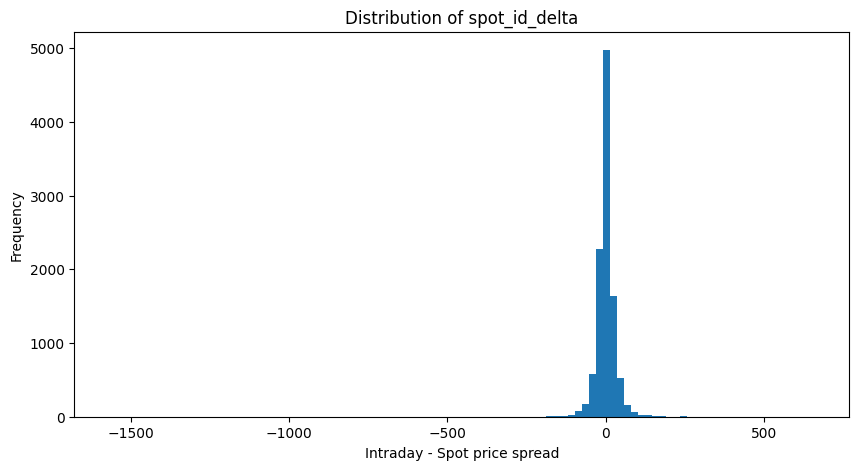

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df["spot_id_delta"], bins=100)
plt.title("Distribution of spot_id_delta")
plt.xlabel("Intraday - Spot price spread")
plt.ylabel("Frequency")
plt.show()

In [ ]:
def weighted_accuracy(y_true, y_pred):
    """
    Weighted Accuracy based on the sign of the prediction.

    y_true: true numerical values of spot_id_delta
    y_pred: predicted numerical values or signs

    The prediction is correct if y_true and y_pred have the same sign.
    Observations are weighted by abs(y_true).
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    correct_sign = (y_true > 0) == (y_pred > 0)
    weights = np.abs(y_true)

    return np.sum(weights * correct_sign) / np.sum(weights)

In [ ]:
# Benchmark: always predict a positive spread
y_true = df["spot_id_delta"]
y_pred_benchmark = np.ones(len(df))

benchmark_score = weighted_accuracy(y_true, y_pred_benchmark)

print("Benchmark Weighted Accuracy:", round(benchmark_score, 4))
print("Benchmark simple accuracy:", round(((y_true > 0) == (y_pred_benchmark > 0)).mean(), 4))

Benchmark Weighted Accuracy: 0.524
Benchmark simple accuracy: 0.5017


In [ ]:
display(df["spot_id_delta"].describe())

print("Number of positive deltas:", (df["spot_id_delta"] > 0).sum())
print("Number of negative deltas:", (df["spot_id_delta"] < 0).sum())
print("Number of zero deltas:", (df["spot_id_delta"] == 0).sum())

print("Share positive:", round((df["spot_id_delta"] > 0).mean(), 4))
print("Share negative:", round((df["spot_id_delta"] < 0).mean(), 4))

print("Benchmark Weighted Accuracy:", round(benchmark_score, 4))
print("Benchmark simple accuracy:", round(((y_true > 0) == (y_pred_benchmark > 0)).mean(), 4))

,spot_id_delta
count,10605.000000
mean,0.943358
std,38.093819
min,-1567.353547
25%,-11.934152
50%,0.059125
75%,12.190489
max,658.961329


Number of positive deltas: 5320
Number of negative deltas: 5285
Number of zero deltas: 0
Share positive: 0.5017
Share negative: 0.4983
Benchmark Weighted Accuracy: 0.524
Benchmark simple accuracy: 0.5017


In [ ]:
def create_features(data):
    """
    Create time-based and electricity-market features.
    Works for both train and test datasets.
    """
    data = data.copy()

    # Time features
    data["hour"] = data["DELIVERY_START"].dt.hour
    data["dayofweek"] = data["DELIVERY_START"].dt.dayofweek
    data["month"] = data["DELIVERY_START"].dt.month
    data["day"] = data["DELIVERY_START"].dt.day
    data["is_weekend"] = data["dayofweek"].isin([5, 6]).astype(int)

    # Peak / off-peak indicators
    data["is_peak_hour"] = data["hour"].between(8, 19).astype(int)
    data["is_night"] = data["hour"].between(0, 6).astype(int)

    # Cyclical encoding for hour
    data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)

    # Cyclical encoding for month
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

    # Electricity market features
    data["renewable_forecast"] = (
        data["wind_power_forecasts_average"]
        + data["solar_power_forecasts_average"]
    )

    data["residual_load"] = (
        data["load_forecast"]
        - data["renewable_forecast"]
    )

    data["dispatchable_capacity"] = (
        data["coal_power_available"]
        + data["gas_power_available"]
        + data["nucelear_power_available"]
    )

    data["system_margin"] = (
        data["dispatchable_capacity"]
        + data["renewable_forecast"]
        - data["load_forecast"]
    )

    data["renewable_share"] = (
        data["renewable_forecast"] / data["load_forecast"]
    )

    data["renewable_uncertainty"] = (
        data["wind_power_forecasts_std"]
        + data["solar_power_forecasts_std"]
    )

    data["wind_uncertainty_ratio"] = (
        data["wind_power_forecasts_std"]
        / data["wind_power_forecasts_average"]
    )

    data["solar_uncertainty_ratio"] = (
        data["solar_power_forecasts_std"]
        / data["solar_power_forecasts_average"]
    )

    # Replace infinite values caused by division by zero
    data = data.replace([np.inf, -np.inf], np.nan)

    return data

In [ ]:
df_features = create_features(df)
X_test_features = create_features(X_test)

print("Train with features:", df_features.shape)
print("Test with features:", X_test_features.shape)

display(df_features.head())

Train with features: (10605, 30)
Test with features: (4942, 29)


,DELIVERY_START,load_forecast,coal_power_available,gas_power_available,nucelear_power_available,wind_power_forecasts_average,solar_power_forecasts_average,wind_power_forecasts_std,solar_power_forecasts_std,predicted_spot_price,...,month_sin,month_cos,renewable_forecast,residual_load,dispatchable_capacity,system_margin,renewable_share,renewable_uncertainty,wind_uncertainty_ratio,solar_uncertainty_ratio
0,2022-01-01 01:00:00+00:00,49439.0,3386.0,11487.0,44118.0,3035.0,0.0,79.248348,0.0,NaN,...,0.5,0.866025,3035.0,46404.0,58991.0,12587.0,0.061389,79.248348,0.026111,NaN
1,2022-01-01 02:00:00+00:00,46511.0,3386.0,11487.0,44118.0,3143.0,0.0,61.776532,0.0,NaN,...,0.5,0.866025,3143.0,43368.0,58991.0,15623.0,0.067575,61.776532,0.019655,NaN
2,2022-01-01 03:00:00+00:00,45158.0,3386.0,11487.0,44118.0,3288.0,0.0,44.291112,0.0,NaN,...,0.5,0.866025,3288.0,41870.0,58991.0,17121.0,0.072811,44.291112,0.013471,NaN
3,2022-01-01 04:00:00+00:00,44779.0,3386.0,11487.0,44118.0,3447.0,0.0,36.127588,0.0,NaN,...,0.5,0.866025,3447.0,41332.0,58991.0,17659.0,0.076978,36.127588,0.010481,NaN
4,2022-01-01 05:00:00+00:00,45284.0,3386.0,11487.0,44118.0,3679.0,0.0,30.983023,0.0,NaN,...,0.5,0.866025,3679.0,41605.0,58991.0,17386.0,0.081243,30.983023,0.008422,NaN


In [ ]:
new_columns = [
    "hour", "dayofweek", "month", "day", "is_weekend",
    "is_peak_hour", "is_night",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "renewable_forecast", "residual_load", "dispatchable_capacity",
    "system_margin", "renewable_share", "renewable_uncertainty",
    "wind_uncertainty_ratio", "solar_uncertainty_ratio"
]

display(df_features[new_columns].head())

,hour,dayofweek,month,day,is_weekend,is_peak_hour,is_night,hour_sin,hour_cos,month_sin,month_cos,renewable_forecast,residual_load,dispatchable_capacity,system_margin,renewable_share,renewable_uncertainty,wind_uncertainty_ratio,solar_uncertainty_ratio
0,1,5,1,1,1,0,1,0.258819,0.965926,0.5,0.866025,3035.0,46404.0,58991.0,12587.0,0.061389,79.248348,0.026111,NaN
1,2,5,1,1,1,0,1,0.500000,0.866025,0.5,0.866025,3143.0,43368.0,58991.0,15623.0,0.067575,61.776532,0.019655,NaN
2,3,5,1,1,1,0,1,0.707107,0.707107,0.5,0.866025,3288.0,41870.0,58991.0,17121.0,0.072811,44.291112,0.013471,NaN
3,4,5,1,1,1,0,1,0.866025,0.500000,0.5,0.866025,3447.0,41332.0,58991.0,17659.0,0.076978,36.127588,0.010481,NaN
4,5,5,1,1,1,0,1,0.965926,0.258819,0.5,0.866025,3679.0,41605.0,58991.0,17386.0,0.081243,30.983023,0.008422,NaN


In [ ]:
missing_features_train = df_features.isna().sum().sort_values(ascending=False)
missing_features_test = X_test_features.isna().sum().sort_values(ascending=False)

print("Missing values after feature engineering - train:")
display(missing_features_train[missing_features_train > 0])

print("Missing values after feature engineering - test:")
display(missing_features_test[missing_features_test > 0])

Missing values after feature engineering - train:


,0
predicted_spot_price,8759
solar_uncertainty_ratio,4708
system_margin,1336
residual_load,1335
renewable_share,1335
load_forecast,1287
renewable_uncertainty,48
renewable_forecast,48
solar_power_forecasts_std,24
wind_uncertainty_ratio,24


Missing values after feature engineering - test:


,0
solar_uncertainty_ratio,1728
predicted_spot_price,1536
solar_power_forecasts_average,24
residual_load,24
solar_power_forecasts_std,24
system_margin,24
renewable_share,24
renewable_uncertainty,24
renewable_forecast,24


In [ ]:
print("Train with features:", df_features.shape)
print("Test with features:", X_test_features.shape)

display(missing_features_train[missing_features_train > 0])
display(missing_features_test[missing_features_test > 0])

Train with features: (10605, 30)
Test with features: (4942, 29)


,0
predicted_spot_price,8759
solar_uncertainty_ratio,4708
system_margin,1336
residual_load,1335
renewable_share,1335
load_forecast,1287
renewable_uncertainty,48
renewable_forecast,48
solar_power_forecasts_std,24
wind_uncertainty_ratio,24


,0
solar_uncertainty_ratio,1728
predicted_spot_price,1536
solar_power_forecasts_average,24
residual_load,24
solar_power_forecasts_std,24
system_margin,24
renewable_share,24
renewable_uncertainty,24
renewable_forecast,24


In [ ]:
# Classification target: 1 if Intraday > Spot, 0 otherwise
df_features["target_direction"] = (df_features["spot_id_delta"] > 0).astype(int)

print(df_features["target_direction"].value_counts())
print(df_features["target_direction"].value_counts(normalize=True))

target_direction
1    5320
0    5285
Name: count, dtype: int64
target_direction
1    0.50165
0    0.49835
Name: proportion, dtype: float64


In [ ]:
excluded_columns = [
    "DELIVERY_START",
    "spot_id_delta",
    "target_direction",
    "predicted_spot_price"
]

feature_cols = [
    col for col in df_features.columns
    if col not in excluded_columns
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 27
['load_forecast', 'coal_power_available', 'gas_power_available', 'nucelear_power_available', 'wind_power_forecasts_average', 'solar_power_forecasts_average', 'wind_power_forecasts_std', 'solar_power_forecasts_std', 'hour', 'dayofweek', 'month', 'day', 'is_weekend', 'is_peak_hour', 'is_night', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'renewable_forecast', 'residual_load', 'dispatchable_capacity', 'system_margin', 'renewable_share', 'renewable_uncertainty', 'wind_uncertainty_ratio', 'solar_uncertainty_ratio']


In [ ]:
validation_start = pd.Timestamp("2023-01-01", tz="UTC")

train_data = df_features[df_features["DELIVERY_START"] < validation_start].copy()
valid_data = df_features[df_features["DELIVERY_START"] >= validation_start].copy()

print("Train period:")
print(train_data["DELIVERY_START"].min(), "to", train_data["DELIVERY_START"].max())
print("Train shape:", train_data.shape)

print("\nValidation period:")
print(valid_data["DELIVERY_START"].min(), "to", valid_data["DELIVERY_START"].max())
print("Validation shape:", valid_data.shape)

Train period:
2022-01-01 01:00:00+00:00 to 2022-12-31 23:00:00+00:00
Train shape: (8519, 31)

Validation period:
2023-01-01 00:00:00+00:00 to 2023-03-29 21:00:00+00:00
Validation shape: (2086, 31)


In [ ]:
X_train_model = train_data[feature_cols]
X_valid_model = valid_data[feature_cols]

y_train_class = train_data["target_direction"]
y_valid_class = valid_data["target_direction"]

y_train_delta = train_data["spot_id_delta"]
y_valid_delta = valid_data["spot_id_delta"]

print("X_train_model:", X_train_model.shape)
print("X_valid_model:", X_valid_model.shape)
print("y_train_class:", y_train_class.shape)
print("y_valid_class:", y_valid_class.shape)

X_train_model: (8519, 27)
X_valid_model: (2086, 27)
y_train_class: (8519,)
y_valid_class: (2086,)


In [ ]:
# Benchmark: always predict positive spread on validation set
y_valid_pred_benchmark_delta = np.ones(len(y_valid_delta))

benchmark_valid_weighted = weighted_accuracy(
    y_true=y_valid_delta,
    y_pred=y_valid_pred_benchmark_delta
)

benchmark_valid_accuracy = (
    (y_valid_delta > 0) == (y_valid_pred_benchmark_delta > 0)
).mean()

print("Validation benchmark weighted accuracy:", round(benchmark_valid_weighted, 4))
print("Validation benchmark simple accuracy:", round(benchmark_valid_accuracy, 4))

Validation benchmark weighted accuracy: 0.6604
Validation benchmark simple accuracy: 0.5839


In [ ]:
print("Number of features:", len(feature_cols))
print("Train shape:", train_data.shape)
print("Validation shape:", valid_data.shape)
print("X_train_model:", X_train_model.shape)
print("X_valid_model:", X_valid_model.shape)

print("Validation benchmark weighted accuracy:", round(benchmark_valid_weighted, 4))
print("Validation benchmark simple accuracy:", round(benchmark_valid_accuracy, 4))

Number of features: 27
Train shape: (8519, 31)
Validation shape: (2086, 31)
X_train_model: (8519, 27)
X_valid_model: (2086, 27)
Validation benchmark weighted accuracy: 0.6604
Validation benchmark simple accuracy: 0.5839


**Logistics Regression**


In [ ]:
### 1. Modèle : Régression Logistique Standard
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
logreg_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [ ]:
logreg_pipeline.fit(X_train_model, y_train_class)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [ ]:
y_valid_pred_class_logreg = logreg_pipeline.predict(X_valid_model)

# Convert class predictions into positive / negative spread signs
y_valid_pred_delta_logreg = np.where(y_valid_pred_class_logreg == 1, 1, -1)

In [ ]:
logreg_valid_accuracy = accuracy_score(y_valid_class, y_valid_pred_class_logreg)

logreg_valid_weighted = weighted_accuracy(
    y_true=y_valid_delta,
    y_pred=y_valid_pred_delta_logreg
)

print("Logistic Regression simple accuracy:", round(logreg_valid_accuracy, 4))
print("Logistic Regression weighted accuracy:", round(logreg_valid_weighted, 4))

print("\nBenchmark weighted accuracy:", round(benchmark_valid_weighted, 4))
print("Difference vs benchmark:", round(logreg_valid_weighted - benchmark_valid_weighted, 4))

Logistic Regression simple accuracy: 0.4247
Logistic Regression weighted accuracy: 0.3899

Benchmark weighted accuracy: 0.6604
Difference vs benchmark: -0.2705


In [ ]:
cm = confusion_matrix(y_valid_class, y_valid_pred_class_logreg)

print("Confusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y_valid_class, y_valid_pred_class_logreg))

Confusion matrix:
[[ 774   94]
 [1106  112]]

Classification report:
              precision    recall  f1-score   support

           0       0.41      0.89      0.56       868
           1       0.54      0.09      0.16      1218

    accuracy                           0.42      2086
   macro avg       0.48      0.49      0.36      2086
weighted avg       0.49      0.42      0.33      2086



In [ ]:
print("Logistic Regression simple accuracy:", round(logreg_valid_accuracy, 4))
print("Logistic Regression weighted accuracy:", round(logreg_valid_weighted, 4))
print("Benchmark weighted accuracy:", round(benchmark_valid_weighted, 4))
print("Difference vs benchmark:", round(logreg_valid_weighted - benchmark_valid_weighted, 4))

print(cm)
print(classification_report(y_valid_class, y_valid_pred_class_logreg))

Logistic Regression simple accuracy: 0.4247
Logistic Regression weighted accuracy: 0.3899
Benchmark weighted accuracy: 0.6604
Difference vs benchmark: -0.2705
[[ 774   94]
 [1106  112]]
              precision    recall  f1-score   support

           0       0.41      0.89      0.56       868
           1       0.54      0.09      0.16      1218

    accuracy                           0.42      2086
   macro avg       0.48      0.49      0.36      2086
weighted avg       0.49      0.42      0.33      2086



In [ ]:
# Get predicted probabilities for the positive class
y_valid_proba_logreg = logreg_pipeline.predict_proba(X_valid_model)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)

scores = []

for threshold in thresholds:
    y_pred_class_threshold = (y_valid_proba_logreg >= threshold).astype(int)
    y_pred_delta_threshold = np.where(y_pred_class_threshold == 1, 1, -1)

    score = weighted_accuracy(
        y_true=y_valid_delta,
        y_pred=y_pred_delta_threshold
    )

    simple_acc = accuracy_score(y_valid_class, y_pred_class_threshold)

    scores.append({
        "threshold": threshold,
        "weighted_accuracy": score,
        "simple_accuracy": simple_acc,
        "positive_predictions": y_pred_class_threshold.sum()
    })

threshold_results = pd.DataFrame(scores)

display(
    threshold_results
    .sort_values("weighted_accuracy", ascending=False)
    .head(10)
)

,threshold,weighted_accuracy,simple_accuracy,positive_predictions
30,0.35,0.683309,0.590125,1933
31,0.36,0.679585,0.581975,1866
29,0.34,0.675567,0.590604,1984
32,0.37,0.674287,0.581016,1784
33,0.38,0.670713,0.569511,1664
28,0.33,0.669614,0.587248,2019
27,0.32,0.668053,0.590604,2044
26,0.31,0.667162,0.589645,2056
25,0.30,0.666701,0.589166,2059
24,0.29,0.664509,0.587728,2064


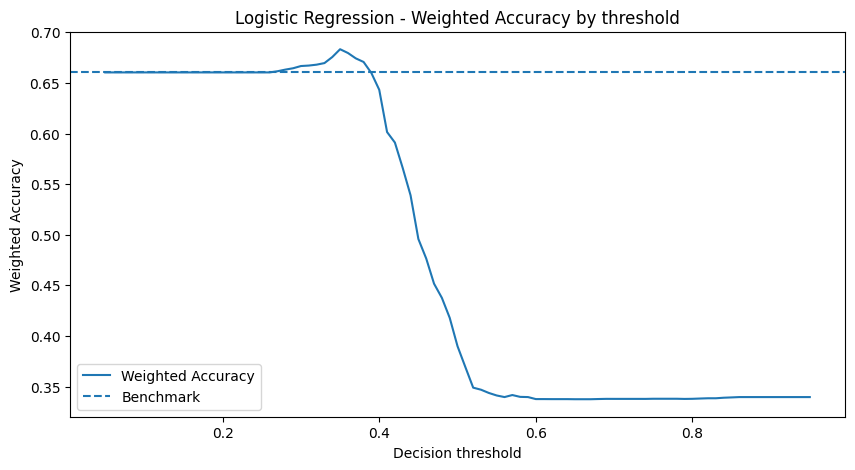

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_results["threshold"], threshold_results["weighted_accuracy"], label="Weighted Accuracy")
plt.axhline(benchmark_valid_weighted, linestyle="--", label="Benchmark")
plt.title("Logistic Regression - Weighted Accuracy by threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Weighted Accuracy")
plt.legend()
plt.show()

Random Forest

In [ ]:
### 2. Modèle : Random Forest
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

In [ ]:
rf_pipeline.fit(X_train_model, y_train_class)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=20, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

In [ ]:
y_valid_pred_class_rf = rf_pipeline.predict(X_valid_model)
y_valid_pred_delta_rf = np.where(y_valid_pred_class_rf == 1, 1, -1)

rf_valid_accuracy = accuracy_score(y_valid_class, y_valid_pred_class_rf)

rf_valid_weighted = weighted_accuracy(
    y_true=y_valid_delta,
    y_pred=y_valid_pred_delta_rf
)

print("Random Forest simple accuracy:", round(rf_valid_accuracy, 4))
print("Random Forest weighted accuracy:", round(rf_valid_weighted, 4))
print("Benchmark weighted accuracy:", round(benchmark_valid_weighted, 4))
print("Difference vs benchmark:", round(rf_valid_weighted - benchmark_valid_weighted, 4))

Random Forest simple accuracy: 0.4506
Random Forest weighted accuracy: 0.3879
Benchmark weighted accuracy: 0.6604
Difference vs benchmark: -0.2725


In [ ]:
y_valid_proba_rf = rf_pipeline.predict_proba(X_valid_model)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)

scores_rf = []

for threshold in thresholds:
    y_pred_class_threshold = (y_valid_proba_rf >= threshold).astype(int)
    y_pred_delta_threshold = np.where(y_pred_class_threshold == 1, 1, -1)

    score = weighted_accuracy(
        y_true=y_valid_delta,
        y_pred=y_pred_delta_threshold
    )

    simple_acc = accuracy_score(y_valid_class, y_pred_class_threshold)

    scores_rf.append({
        "threshold": threshold,
        "weighted_accuracy": score,
        "simple_accuracy": simple_acc,
        "positive_predictions": y_pred_class_threshold.sum()
    })

threshold_results_rf = pd.DataFrame(scores_rf)

display(
    threshold_results_rf
    .sort_values("weighted_accuracy", ascending=False)
    .head(10)
)

,threshold,weighted_accuracy,simple_accuracy,positive_predictions
28,0.33,0.672068,0.593480,1762
29,0.34,0.669422,0.591563,1734
27,0.32,0.668173,0.592042,1797
26,0.31,0.664516,0.592522,1832
30,0.35,0.662325,0.590125,1703
5,0.10,0.660402,0.583893,2086
6,0.11,0.660402,0.583893,2086
3,0.08,0.660402,0.583893,2086
4,0.09,0.660402,0.583893,2086
1,0.06,0.660402,0.583893,2086


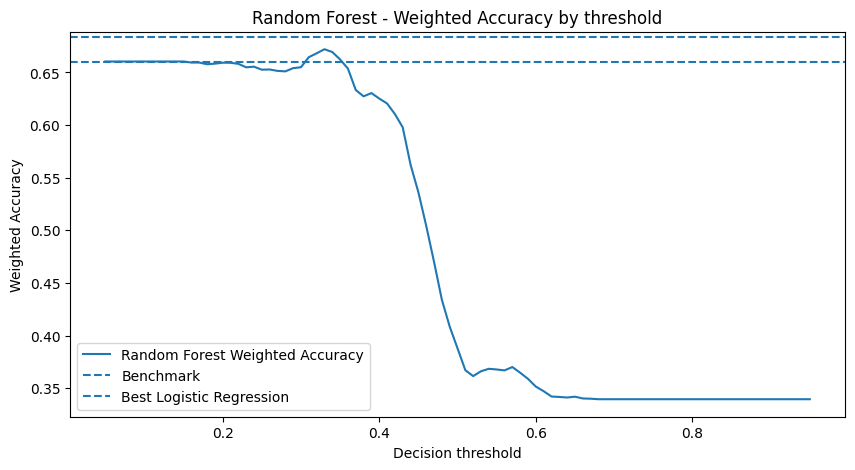

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_results_rf["threshold"], threshold_results_rf["weighted_accuracy"], label="Random Forest Weighted Accuracy")
plt.axhline(benchmark_valid_weighted, linestyle="--", label="Benchmark")
plt.axhline(threshold_results["weighted_accuracy"].max(), linestyle="--", label="Best Logistic Regression")
plt.title("Random Forest - Weighted Accuracy by threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Weighted Accuracy")
plt.legend()
plt.show()

In [ ]:
print("Random Forest simple accuracy:", round(rf_valid_accuracy, 4))
print("Random Forest weighted accuracy:", round(rf_valid_weighted, 4))
print("Benchmark weighted accuracy:", round(benchmark_valid_weighted, 4))

display(
    threshold_results_rf
    .sort_values("weighted_accuracy", ascending=False)
    .head(10)
)

Random Forest simple accuracy: 0.4506
Random Forest weighted accuracy: 0.3879
Benchmark weighted accuracy: 0.6604


,threshold,weighted_accuracy,simple_accuracy,positive_predictions
28,0.33,0.672068,0.593480,1762
29,0.34,0.669422,0.591563,1734
27,0.32,0.668173,0.592042,1797
26,0.31,0.664516,0.592522,1832
30,0.35,0.662325,0.590125,1703
5,0.10,0.660402,0.583893,2086
6,0.11,0.660402,0.583893,2086
3,0.08,0.660402,0.583893,2086
4,0.09,0.660402,0.583893,2086
1,0.06,0.660402,0.583893,2086


In [ ]:
### 3. Modèle : HistGradientBoosting
from sklearn.ensemble import HistGradientBoostingClassifier

In [ ]:
hgb_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    ))
])

In [ ]:
hgb_pipeline.fit(X_train_model, y_train_class)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 HistGradientBoostingClassifier(l2_regularization=0.1,
                                                learning_rate=0.03,
                                                max_iter=300,
                                                random_state=42))])

In [ ]:
y_valid_pred_class_hgb = hgb_pipeline.predict(X_valid_model)
y_valid_pred_delta_hgb = np.where(y_valid_pred_class_hgb == 1, 1, -1)

hgb_valid_accuracy = accuracy_score(y_valid_class, y_valid_pred_class_hgb)

hgb_valid_weighted = weighted_accuracy(
    y_true=y_valid_delta,
    y_pred=y_valid_pred_delta_hgb
)

print("HistGradientBoosting simple accuracy:", round(hgb_valid_accuracy, 4))
print("HistGradientBoosting weighted accuracy:", round(hgb_valid_weighted, 4))
print("Benchmark weighted accuracy:", round(benchmark_valid_weighted, 4))
print("Best Logistic Regression weighted accuracy:", round(threshold_results["weighted_accuracy"].max(), 4))

HistGradientBoosting simple accuracy: 0.4535
HistGradientBoosting weighted accuracy: 0.4007
Benchmark weighted accuracy: 0.6604
Best Logistic Regression weighted accuracy: 0.6833


In [ ]:
y_valid_proba_hgb = hgb_pipeline.predict_proba(X_valid_model)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)

scores_hgb = []

for threshold in thresholds:
    y_pred_class_threshold = (y_valid_proba_hgb >= threshold).astype(int)
    y_pred_delta_threshold = np.where(y_pred_class_threshold == 1, 1, -1)

    score = weighted_accuracy(
        y_true=y_valid_delta,
        y_pred=y_pred_delta_threshold
    )

    simple_acc = accuracy_score(y_valid_class, y_pred_class_threshold)

    scores_hgb.append({
        "threshold": threshold,
        "weighted_accuracy": score,
        "simple_accuracy": simple_acc,
        "positive_predictions": y_pred_class_threshold.sum()
    })

threshold_results_hgb = pd.DataFrame(scores_hgb)

display(
    threshold_results_hgb
    .sort_values("weighted_accuracy", ascending=False)
    .head(10)
)

,threshold,weighted_accuracy,simple_accuracy,positive_predictions
11,0.16,0.666757,0.595877,2005
10,0.15,0.665675,0.594439,2020
13,0.18,0.665107,0.598754,1979
12,0.17,0.664920,0.597315,1992
7,0.12,0.664329,0.592042,2051
9,0.14,0.664290,0.593480,2028
6,0.11,0.664105,0.590125,2059
8,0.13,0.663294,0.593480,2042
5,0.10,0.662996,0.587248,2069
3,0.08,0.661160,0.584851,2082


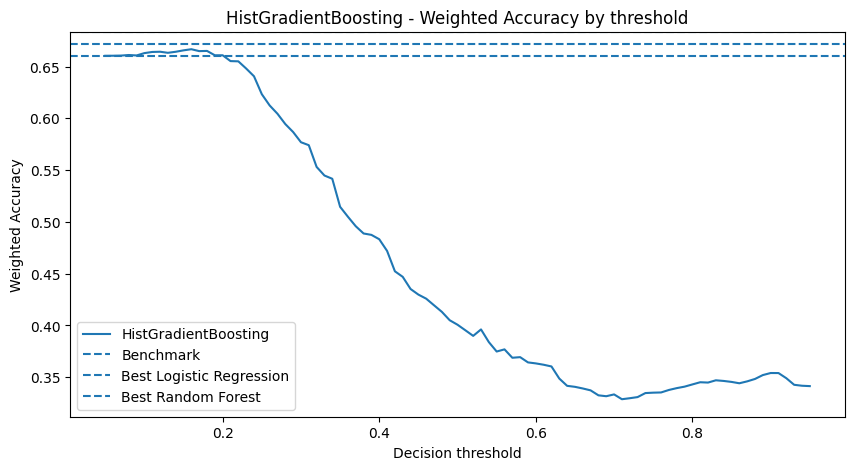

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    threshold_results_hgb["threshold"],
    threshold_results_hgb["weighted_accuracy"],
    label="HistGradientBoosting"
)

plt.axhline(
    benchmark_valid_weighted,
    linestyle="--",
    label="Benchmark"
)

plt.axhline(
    threshold_results["weighted_accuracy"].max(),
    linestyle="--",
    label="Best Logistic Regression"
)

plt.axhline(
    threshold_results_rf["weighted_accuracy"].max(),
    linestyle="--",
    label="Best Random Forest"
)

plt.title("HistGradientBoosting - Weighted Accuracy by threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Weighted Accuracy")
plt.legend()
plt.show()

In [ ]:
print("HistGradientBoosting simple accuracy:", round(hgb_valid_accuracy, 4))
print("HistGradientBoosting weighted accuracy:", round(hgb_valid_weighted, 4))
print("Benchmark weighted accuracy:", round(benchmark_valid_weighted, 4))
print("Best Logistic Regression weighted accuracy:", round(threshold_results["weighted_accuracy"].max(), 4))
print("Best Random Forest weighted accuracy:", round(threshold_results_rf["weighted_accuracy"].max(), 4))

display(
    threshold_results_hgb
    .sort_values("weighted_accuracy", ascending=False)
    .head(10)
)

HistGradientBoosting simple accuracy: 0.4535
HistGradientBoosting weighted accuracy: 0.4007
Benchmark weighted accuracy: 0.6604
Best Logistic Regression weighted accuracy: 0.6833
Best Random Forest weighted accuracy: 0.6721


,threshold,weighted_accuracy,simple_accuracy,positive_predictions
11,0.16,0.666757,0.595877,2005
10,0.15,0.665675,0.594439,2020
13,0.18,0.665107,0.598754,1979
12,0.17,0.664920,0.597315,1992
7,0.12,0.664329,0.592042,2051
9,0.14,0.664290,0.593480,2028
6,0.11,0.664105,0.590125,2059
8,0.13,0.663294,0.593480,2042
5,0.10,0.662996,0.587248,2069
3,0.08,0.661160,0.584851,2082


In [ ]:
# Sample weights based on the absolute size of the spread
sample_weights_train = np.abs(y_train_delta)

print(sample_weights_train.describe())

count    8519.000000
mean       21.631137
std        35.608661
min         0.005374
25%         5.810899
50%        13.598521
75%        27.716437
max      1567.353547
Name: spot_id_delta, dtype: float64


In [ ]:
### 4. Modèle : Régression Logistique Pondérée (Weighted)
weighted_logreg_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

weighted_logreg_pipeline.fit(
    X_train_model,
    y_train_class,
    model__sample_weight=sample_weights_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
y_valid_pred_class_weighted_logreg = weighted_logreg_pipeline.predict(X_valid_model)
y_valid_pred_delta_weighted_logreg = np.where(
    y_valid_pred_class_weighted_logreg == 1,
    1,
    -1
)

weighted_logreg_accuracy = accuracy_score(
    y_valid_class,
    y_valid_pred_class_weighted_logreg
)

weighted_logreg_score = weighted_accuracy(
    y_true=y_valid_delta,
    y_pred=y_valid_pred_delta_weighted_logreg
)

print("Weighted Logistic Regression simple accuracy:", round(weighted_logreg_accuracy, 4))
print("Weighted Logistic Regression weighted accuracy:", round(weighted_logreg_score, 4))
print("Best previous Logistic Regression:", round(threshold_results["weighted_accuracy"].max(), 4))
print("Benchmark:", round(benchmark_valid_weighted, 4))

Weighted Logistic Regression simple accuracy: 0.4372
Weighted Logistic Regression weighted accuracy: 0.4062
Best previous Logistic Regression: 0.6833
Benchmark: 0.6604


In [ ]:
y_valid_proba_weighted_logreg = weighted_logreg_pipeline.predict_proba(X_valid_model)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)

scores_weighted_logreg = []

for threshold in thresholds:
    y_pred_class_threshold = (y_valid_proba_weighted_logreg >= threshold).astype(int)
    y_pred_delta_threshold = np.where(y_pred_class_threshold == 1, 1, -1)

    score = weighted_accuracy(
        y_true=y_valid_delta,
        y_pred=y_pred_delta_threshold
    )

    simple_acc = accuracy_score(y_valid_class, y_pred_class_threshold)

    scores_weighted_logreg.append({
        "threshold": threshold,
        "weighted_accuracy": score,
        "simple_accuracy": simple_acc,
        "positive_predictions": y_pred_class_threshold.sum()
    })

threshold_results_weighted_logreg = pd.DataFrame(scores_weighted_logreg)

display(
    threshold_results_weighted_logreg
    .sort_values("weighted_accuracy", ascending=False)
    .head(10)
)

,threshold,weighted_accuracy,simple_accuracy,positive_predictions
27,0.32,0.688332,0.590604,1720
30,0.35,0.687192,0.581496,1501
26,0.31,0.686065,0.589166,1789
29,0.34,0.686042,0.585331,1569
28,0.33,0.685207,0.590125,1647
21,0.26,0.683789,0.593960,1987
22,0.27,0.683274,0.594919,1963
20,0.25,0.682575,0.593001,1997
25,0.30,0.680648,0.591083,1847
24,0.29,0.678813,0.592042,1901


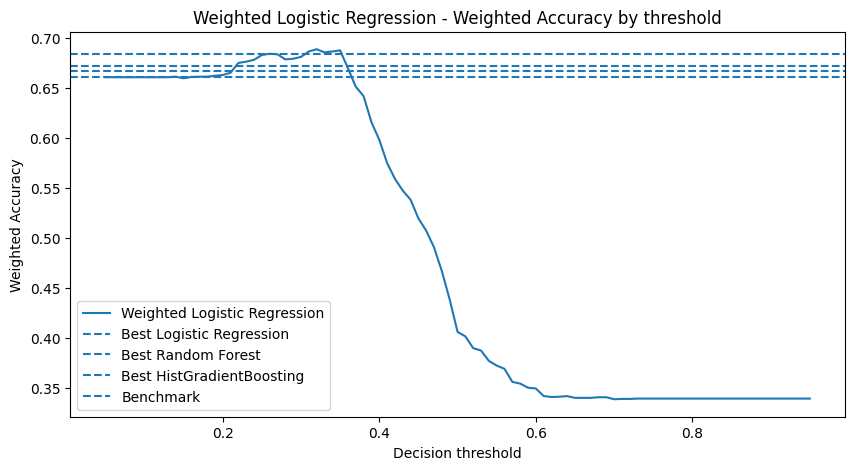

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    threshold_results_weighted_logreg["threshold"],
    threshold_results_weighted_logreg["weighted_accuracy"],
    label="Weighted Logistic Regression"
)

plt.axhline(
    threshold_results["weighted_accuracy"].max(),
    linestyle="--",
    label="Best Logistic Regression"
)

plt.axhline(
    threshold_results_rf["weighted_accuracy"].max(),
    linestyle="--",
    label="Best Random Forest"
)

plt.axhline(
    threshold_results_hgb["weighted_accuracy"].max(),
    linestyle="--",
    label="Best HistGradientBoosting"
)

plt.axhline(
    benchmark_valid_weighted,
    linestyle="--",
    label="Benchmark"
)

plt.title("Weighted Logistic Regression - Weighted Accuracy by threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Weighted Accuracy")
plt.legend()
plt.show()

In [ ]:
print("Weighted Logistic Regression simple accuracy:", round(weighted_logreg_accuracy, 4))
print("Weighted Logistic Regression weighted accuracy:", round(weighted_logreg_score, 4))
print("Best previous Logistic Regression:", round(threshold_results["weighted_accuracy"].max(), 4))
print("Benchmark:", round(benchmark_valid_weighted, 4))

display(
    threshold_results_weighted_logreg
    .sort_values("weighted_accuracy", ascending=False)
    .head(10)
)

Weighted Logistic Regression simple accuracy: 0.4372
Weighted Logistic Regression weighted accuracy: 0.4062
Best previous Logistic Regression: 0.6833
Benchmark: 0.6604


,threshold,weighted_accuracy,simple_accuracy,positive_predictions
27,0.32,0.688332,0.590604,1720
30,0.35,0.687192,0.581496,1501
26,0.31,0.686065,0.589166,1789
29,0.34,0.686042,0.585331,1569
28,0.33,0.685207,0.590125,1647
21,0.26,0.683789,0.593960,1987
22,0.27,0.683274,0.594919,1963
20,0.25,0.682575,0.593001,1997
25,0.30,0.680648,0.591083,1847
24,0.29,0.678813,0.592042,1901


In [ ]:
weighted_hgb_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    ))
])

In [ ]:
weighted_hgb_pipeline.fit(
    X_train_model,
    y_train_class,
    model__sample_weight=sample_weights_train
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 HistGradientBoostingClassifier(l2_regularization=0.1,
                                                learning_rate=0.03,
                                                max_iter=300,
                                                random_state=42))])

In [ ]:
y_valid_pred_class_weighted_hgb = weighted_hgb_pipeline.predict(X_valid_model)

y_valid_pred_delta_weighted_hgb = np.where(
    y_valid_pred_class_weighted_hgb == 1,
    1,
    -1
)

weighted_hgb_accuracy = accuracy_score(
    y_valid_class,
    y_valid_pred_class_weighted_hgb
)

weighted_hgb_score = weighted_accuracy(
    y_true=y_valid_delta,
    y_pred=y_valid_pred_delta_weighted_hgb
)

print("Weighted HGB simple accuracy:", round(weighted_hgb_accuracy, 4))
print("Weighted HGB weighted accuracy:", round(weighted_hgb_score, 4))
print("Best weighted Logistic Regression:", round(threshold_results_weighted_logreg["weighted_accuracy"].max(), 4))
print("Benchmark:", round(benchmark_valid_weighted, 4))

Weighted HGB simple accuracy: 0.4497
Weighted HGB weighted accuracy: 0.3874
Best weighted Logistic Regression: 0.6883
Benchmark: 0.6604


In [ ]:
y_valid_proba_weighted_hgb = weighted_hgb_pipeline.predict_proba(X_valid_model)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)

scores_weighted_hgb = []

for threshold in thresholds:
    y_pred_class_threshold = (y_valid_proba_weighted_hgb >= threshold).astype(int)
    y_pred_delta_threshold = np.where(y_pred_class_threshold == 1, 1, -1)

    score = weighted_accuracy(
        y_true=y_valid_delta,
        y_pred=y_pred_delta_threshold
    )

    simple_acc = accuracy_score(y_valid_class, y_pred_class_threshold)

    scores_weighted_hgb.append({
        "threshold": threshold,
        "weighted_accuracy": score,
        "simple_accuracy": simple_acc,
        "positive_predictions": y_pred_class_threshold.sum()
    })

threshold_results_weighted_hgb = pd.DataFrame(scores_weighted_hgb)

display(
    threshold_results_weighted_hgb
    .sort_values("weighted_accuracy", ascending=False)
    .head(10)
)

,threshold,weighted_accuracy,simple_accuracy,positive_predictions
0,0.05,0.661217,0.586290,2071
1,0.06,0.657958,0.585331,2059
2,0.07,0.654573,0.584851,2046
3,0.08,0.645064,0.584372,2025
4,0.09,0.645036,0.585810,2016
5,0.10,0.643713,0.586290,2005
6,0.11,0.642704,0.587728,1986
7,0.12,0.641613,0.587248,1965
8,0.13,0.638224,0.584372,1941
9,0.14,0.634228,0.583413,1917


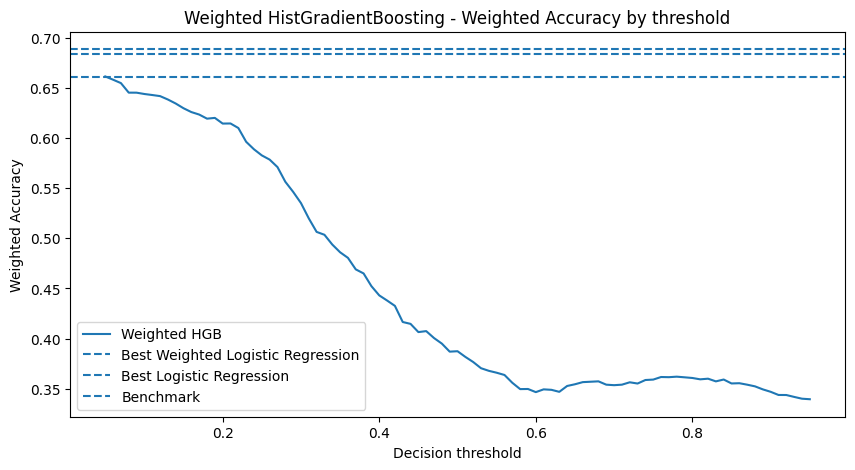

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    threshold_results_weighted_hgb["threshold"],
    threshold_results_weighted_hgb["weighted_accuracy"],
    label="Weighted HGB"
)

plt.axhline(
    threshold_results_weighted_logreg["weighted_accuracy"].max(),
    linestyle="--",
    label="Best Weighted Logistic Regression"
)

plt.axhline(
    threshold_results["weighted_accuracy"].max(),
    linestyle="--",
    label="Best Logistic Regression"
)

plt.axhline(
    benchmark_valid_weighted,
    linestyle="--",
    label="Benchmark"
)

plt.title("Weighted HistGradientBoosting - Weighted Accuracy by threshold")
plt.xlabel("Decision threshold")
plt.ylabel("Weighted Accuracy")
plt.legend()
plt.show()

In [ ]:
print("Weighted HGB simple accuracy:", round(weighted_hgb_accuracy, 4))
print("Weighted HGB weighted accuracy:", round(weighted_hgb_score, 4))
print("Best weighted Logistic Regression:", round(threshold_results_weighted_logreg["weighted_accuracy"].max(), 4))
print("Benchmark:", round(benchmark_valid_weighted, 4))

display(
    threshold_results_weighted_hgb
    .sort_values("weighted_accuracy", ascending=False)
    .head(10)
)

Weighted HGB simple accuracy: 0.4497
Weighted HGB weighted accuracy: 0.3874
Best weighted Logistic Regression: 0.6883
Benchmark: 0.6604


,threshold,weighted_accuracy,simple_accuracy,positive_predictions
0,0.05,0.661217,0.586290,2071
1,0.06,0.657958,0.585331,2059
2,0.07,0.654573,0.584851,2046
3,0.08,0.645064,0.584372,2025
4,0.09,0.645036,0.585810,2016
5,0.10,0.643713,0.586290,2005
6,0.11,0.642704,0.587728,1986
7,0.12,0.641613,0.587248,1965
8,0.13,0.638224,0.584372,1941
9,0.14,0.634228,0.583413,1917


In [ ]:
sample_weights_train.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

,spot_id_delta
count,8519.000000
mean,21.631137
std,35.608661
min,0.005374
50%,13.598521
75%,27.716437
90%,46.280456
95%,64.872064
99%,123.955668
max,1567.353547


In [ ]:
### 5. Modèle Final : Régression Logistique Pondérée et Plafonnée (Capped Weighted)
cap_95 = sample_weights_train.quantile(0.95)
sample_weights_train_capped = sample_weights_train.clip(upper=cap_95)

print("Cap 95%:", cap_95)
print(sample_weights_train_capped.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

Cap 95%: 64.87206416864932
count    8519.000000
mean       19.281515
std        17.576038
min         0.005374
50%        13.598521
75%        27.716437
90%        46.280456
95%        64.869947
99%        64.872064
max        64.872064
Name: spot_id_delta, dtype: float64


In [ ]:
capped_weighted_logreg_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

capped_weighted_logreg_pipeline.fit(
    X_train_model,
    y_train_class,
    model__sample_weight=sample_weights_train_capped
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
y_valid_proba_capped_logreg = capped_weighted_logreg_pipeline.predict_proba(X_valid_model)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.01)

scores_capped_logreg = []

for threshold in thresholds:
    y_pred_class_threshold = (y_valid_proba_capped_logreg >= threshold).astype(int)
    y_pred_delta_threshold = np.where(y_pred_class_threshold == 1, 1, -1)

    score = weighted_accuracy(
        y_true=y_valid_delta,
        y_pred=y_pred_delta_threshold
    )

    simple_acc = accuracy_score(y_valid_class, y_pred_class_threshold)

    scores_capped_logreg.append({
        "threshold": threshold,
        "weighted_accuracy": score,
        "simple_accuracy": simple_acc,
        "positive_predictions": y_pred_class_threshold.sum()
    })

threshold_results_capped_logreg = pd.DataFrame(scores_capped_logreg)

display(
    threshold_results_capped_logreg
    .sort_values("weighted_accuracy", ascending=False)
    .head(10)
)

,threshold,weighted_accuracy,simple_accuracy,positive_predictions
26,0.31,0.690273,0.592522,1738
25,0.30,0.687012,0.595877,1799
24,0.29,0.685158,0.595398,1860
28,0.33,0.684448,0.579578,1555
29,0.34,0.683594,0.581975,1470
23,0.28,0.680360,0.593960,1905
19,0.24,0.678494,0.588686,2020
20,0.25,0.678254,0.589166,1999
21,0.26,0.677905,0.590125,1977
27,0.32,0.677731,0.580537,1651


In [ ]:
print("Benchmark:", round(benchmark_valid_weighted, 4))
print("Best Logistic Regression:", round(threshold_results["weighted_accuracy"].max(), 4))
print("Best Weighted Logistic Regression:", round(threshold_results_weighted_logreg["weighted_accuracy"].max(), 4))
print("Best Capped Weighted Logistic Regression:", round(threshold_results_capped_logreg["weighted_accuracy"].max(), 4))

Benchmark: 0.6604
Best Logistic Regression: 0.6833
Best Weighted Logistic Regression: 0.6883
Best Capped Weighted Logistic Regression: 0.6903


In [ ]:
print("Cap 95%:", cap_95)

print("Benchmark:", round(benchmark_valid_weighted, 4))
print("Best Logistic Regression:", round(threshold_results["weighted_accuracy"].max(), 4))
print("Best Weighted Logistic Regression:", round(threshold_results_weighted_logreg["weighted_accuracy"].max(), 4))
print("Best Capped Weighted Logistic Regression:", round(threshold_results_capped_logreg["weighted_accuracy"].max(), 4))

display(
    threshold_results_capped_logreg
    .sort_values("weighted_accuracy", ascending=False)
    .head(10)
)

Cap 95%: 64.87206416864932
Benchmark: 0.6604
Best Logistic Regression: 0.6833
Best Weighted Logistic Regression: 0.6883
Best Capped Weighted Logistic Regression: 0.6903


,threshold,weighted_accuracy,simple_accuracy,positive_predictions
26,0.31,0.690273,0.592522,1738
25,0.30,0.687012,0.595877,1799
24,0.29,0.685158,0.595398,1860
28,0.33,0.684448,0.579578,1555
29,0.34,0.683594,0.581975,1470
23,0.28,0.680360,0.593960,1905
19,0.24,0.678494,0.588686,2020
20,0.25,0.678254,0.589166,1999
21,0.26,0.677905,0.590125,1977
27,0.32,0.677731,0.580537,1651


In [ ]:
model_comparison = pd.DataFrame([
    {
        "model": "Benchmark always positive",
        "best_threshold": None,
        "weighted_accuracy": benchmark_valid_weighted
    },
    {
        "model": "Logistic Regression",
        "best_threshold": threshold_results.sort_values("weighted_accuracy", ascending=False).iloc[0]["threshold"],
        "weighted_accuracy": threshold_results["weighted_accuracy"].max()
    },
    {
        "model": "Random Forest",
        "best_threshold": threshold_results_rf.sort_values("weighted_accuracy", ascending=False).iloc[0]["threshold"],
        "weighted_accuracy": threshold_results_rf["weighted_accuracy"].max()
    },
    {
        "model": "HistGradientBoosting",
        "best_threshold": threshold_results_hgb.sort_values("weighted_accuracy", ascending=False).iloc[0]["threshold"],
        "weighted_accuracy": threshold_results_hgb["weighted_accuracy"].max()
    },
    {
        "model": "Weighted Logistic Regression",
        "best_threshold": threshold_results_weighted_logreg.sort_values("weighted_accuracy", ascending=False).iloc[0]["threshold"],
        "weighted_accuracy": threshold_results_weighted_logreg["weighted_accuracy"].max()
    },
    {
        "model": "Capped Weighted Logistic Regression",
        "best_threshold": threshold_results_capped_logreg.sort_values("weighted_accuracy", ascending=False).iloc[0]["threshold"],
        "weighted_accuracy": threshold_results_capped_logreg["weighted_accuracy"].max()
    }
])

model_comparison = model_comparison.sort_values("weighted_accuracy", ascending=False)

display(model_comparison)

,model,best_threshold,weighted_accuracy
5,Capped Weighted Logistic Regression,0.31,0.690273
4,Weighted Logistic Regression,0.32,0.688332
1,Logistic Regression,0.35,0.683309
2,Random Forest,0.33,0.672068
3,HistGradientBoosting,0.16,0.666757
0,Benchmark always positive,NaN,0.660402


In [ ]:
best_model = capped_weighted_logreg_pipeline
best_threshold = 0.31

print("Best model: Capped Weighted Logistic Regression")
print("Best threshold:", best_threshold)
print("Best validation weighted accuracy:", round(threshold_results_capped_logreg["weighted_accuracy"].max(), 4))

Best model: Capped Weighted Logistic Regression
Best threshold: 0.31
Best validation weighted accuracy: 0.6903


In [ ]:
# Extract logistic regression coefficients
coefficients = best_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

display(coef_df.head(15))

,feature,coefficient,abs_coefficient
0,load_forecast,1.890325,1.890325
20,residual_load,-1.579836,1.579836
19,renewable_forecast,-1.511807,1.511807
4,wind_power_forecasts_average,1.213833,1.213833
5,solar_power_forecasts_average,0.772384,0.772384
24,renewable_uncertainty,-0.570422,0.570422
6,wind_power_forecasts_std,0.430988,0.430988
2,gas_power_available,-0.411819,0.411819
23,renewable_share,-0.365103,0.365103
7,solar_power_forecasts_std,0.307758,0.307758


In [ ]:
print("Top positive coefficients:")
display(
    coef_df
    .sort_values("coefficient", ascending=False)
    .head(10)
)

print("Top negative coefficients:")
display(
    coef_df
    .sort_values("coefficient", ascending=True)
    .head(10)
)

Top positive coefficients:


,feature,coefficient,abs_coefficient
0,load_forecast,1.890325,1.890325
4,wind_power_forecasts_average,1.213833,1.213833
5,solar_power_forecasts_average,0.772384,0.772384
6,wind_power_forecasts_std,0.430988,0.430988
7,solar_power_forecasts_std,0.307758,0.307758
17,month_sin,0.205156,0.205156
10,month,0.204012,0.204012
25,wind_uncertainty_ratio,0.185861,0.185861
1,coal_power_available,0.181202,0.181202
18,month_cos,0.143613,0.143613


Top negative coefficients:


,feature,coefficient,abs_coefficient
20,residual_load,-1.579836,1.579836
19,renewable_forecast,-1.511807,1.511807
24,renewable_uncertainty,-0.570422,0.570422
2,gas_power_available,-0.411819,0.411819
23,renewable_share,-0.365103,0.365103
3,nucelear_power_available,-0.232960,0.232960
21,dispatchable_capacity,-0.205619,0.205619
14,is_night,-0.159698,0.159698
12,is_weekend,-0.122855,0.122855
8,hour,-0.118444,0.118444


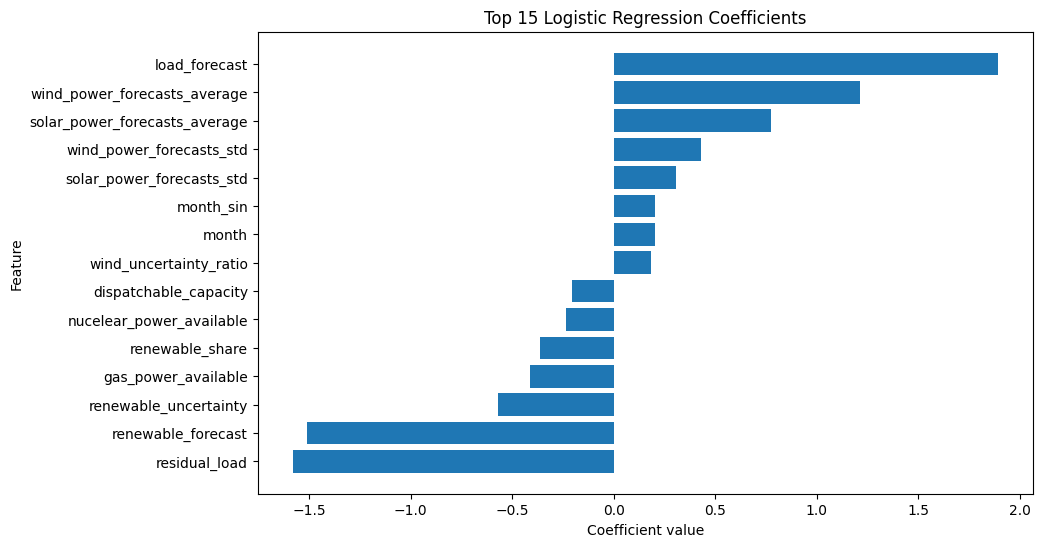

In [ ]:
top_coef = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.title("Top 15 Logistic Regression Coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.show()

In [ ]:
display(model_comparison)
display(coef_df.head(15))

,model,best_threshold,weighted_accuracy
5,Capped Weighted Logistic Regression,0.31,0.690273
4,Weighted Logistic Regression,0.32,0.688332
1,Logistic Regression,0.35,0.683309
2,Random Forest,0.33,0.672068
3,HistGradientBoosting,0.16,0.666757
0,Benchmark always positive,NaN,0.660402


,feature,coefficient,abs_coefficient
0,load_forecast,1.890325,1.890325
20,residual_load,-1.579836,1.579836
19,renewable_forecast,-1.511807,1.511807
4,wind_power_forecasts_average,1.213833,1.213833
5,solar_power_forecasts_average,0.772384,0.772384
24,renewable_uncertainty,-0.570422,0.570422
6,wind_power_forecasts_std,0.430988,0.430988
2,gas_power_available,-0.411819,0.411819
23,renewable_share,-0.365103,0.365103
7,solar_power_forecasts_std,0.307758,0.307758


In [ ]:
# Best model predictions on validation set
y_valid_proba_best = best_model.predict_proba(X_valid_model)[:, 1]

y_valid_pred_class_best = (y_valid_proba_best >= best_threshold).astype(int)

y_valid_pred_delta_best = np.where(
    y_valid_pred_class_best == 1,
    1,
    -1
)

best_valid_weighted = weighted_accuracy(
    y_true=y_valid_delta,
    y_pred=y_valid_pred_delta_best
)

best_valid_accuracy = accuracy_score(
    y_valid_class,
    y_valid_pred_class_best
)

print("Best model simple accuracy:", round(best_valid_accuracy, 4))
print("Best model weighted accuracy:", round(best_valid_weighted, 4))
print("Positive predictions:", y_valid_pred_class_best.sum())
print("Negative predictions:", len(y_valid_pred_class_best) - y_valid_pred_class_best.sum())

Best model simple accuracy: 0.5925
Best model weighted accuracy: 0.6903
Positive predictions: 1738
Negative predictions: 348


In [ ]:
cm_best = confusion_matrix(y_valid_class, y_valid_pred_class_best)

print("Confusion matrix:")
print(cm_best)

print("\nClassification report:")
print(classification_report(y_valid_class, y_valid_pred_class_best))

Confusion matrix:
[[ 183  685]
 [ 165 1053]]

Classification report:
              precision    recall  f1-score   support

           0       0.53      0.21      0.30       868
           1       0.61      0.86      0.71      1218

    accuracy                           0.59      2086
   macro avg       0.57      0.54      0.51      2086
weighted avg       0.57      0.59      0.54      2086



In [ ]:
valid_analysis = valid_data.copy()

valid_analysis["pred_proba_positive"] = y_valid_proba_best
valid_analysis["pred_class"] = y_valid_pred_class_best
valid_analysis["true_class"] = y_valid_class.values
valid_analysis["correct_prediction"] = (
    valid_analysis["pred_class"] == valid_analysis["true_class"]
).astype(int)

valid_analysis["abs_delta"] = valid_analysis["spot_id_delta"].abs()

display(valid_analysis[[
    "DELIVERY_START",
    "spot_id_delta",
    "abs_delta",
    "true_class",
    "pred_class",
    "pred_proba_positive",
    "correct_prediction"
]].head())

,DELIVERY_START,spot_id_delta,abs_delta,true_class,pred_class,pred_proba_positive,correct_prediction
8519,2023-01-01 00:00:00+00:00,-2.992829,2.992829,0,1,0.332046,0
8520,2023-01-01 01:00:00+00:00,-1.598581,1.598581,0,1,0.322414,0
8521,2023-01-01 02:00:00+00:00,-0.570908,0.570908,0,0,0.283458,1
8522,2023-01-01 03:00:00+00:00,-1.451732,1.451732,0,0,0.258472,1
8523,2023-01-01 04:00:00+00:00,-1.856010,1.856010,0,0,0.253458,1


In [ ]:
hourly_scores = []

for hour, group in valid_analysis.groupby("hour"):
    score = weighted_accuracy(
        y_true=group["spot_id_delta"],
        y_pred=np.where(group["pred_class"] == 1, 1, -1)
    )

    simple_acc = group["correct_prediction"].mean()

    hourly_scores.append({
        "hour": hour,
        "weighted_accuracy": score,
        "simple_accuracy": simple_acc,
        "count": len(group)
    })

hourly_scores = pd.DataFrame(hourly_scores)

display(hourly_scores)

,hour,weighted_accuracy,simple_accuracy,count
0,0,0.585859,0.551724,87
1,1,0.644217,0.586207,87
2,2,0.649443,0.574713,87
3,3,0.635800,0.597701,87
4,4,0.586291,0.551724,87
5,5,0.650060,0.632184,87
6,6,0.681784,0.586207,87
7,7,0.678417,0.540230,87
8,8,0.714267,0.597701,87
9,9,0.727795,0.574713,87


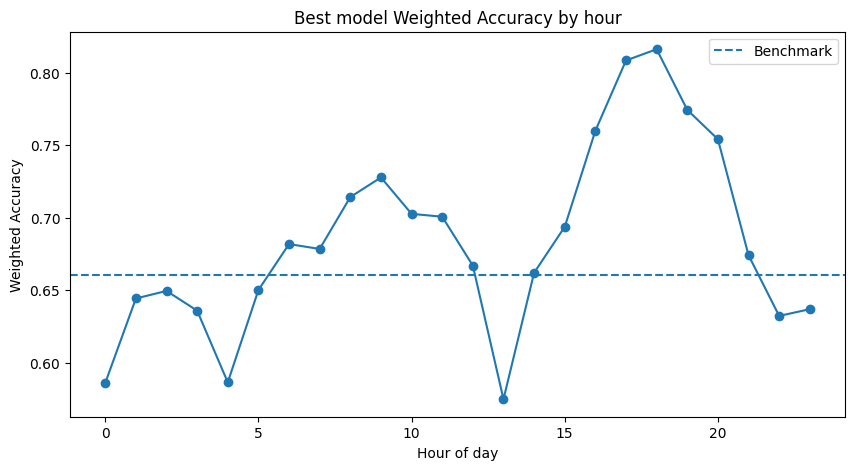

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_scores["hour"], hourly_scores["weighted_accuracy"], marker="o")
plt.axhline(benchmark_valid_weighted, linestyle="--", label="Benchmark")
plt.title("Best model Weighted Accuracy by hour")
plt.xlabel("Hour of day")
plt.ylabel("Weighted Accuracy")
plt.legend()
plt.show()

In [ ]:
print("Best model simple accuracy:", round(best_valid_accuracy, 4))
print("Best model weighted accuracy:", round(best_valid_weighted, 4))
print("Positive predictions:", y_valid_pred_class_best.sum())
print("Negative predictions:", len(y_valid_pred_class_best) - y_valid_pred_class_best.sum())

print(cm_best)
print(classification_report(y_valid_class, y_valid_pred_class_best))

display(hourly_scores)

Best model simple accuracy: 0.5925
Best model weighted accuracy: 0.6903
Positive predictions: 1738
Negative predictions: 348
[[ 183  685]
 [ 165 1053]]
              precision    recall  f1-score   support

           0       0.53      0.21      0.30       868
           1       0.61      0.86      0.71      1218

    accuracy                           0.59      2086
   macro avg       0.57      0.54      0.51      2086
weighted avg       0.57      0.59      0.54      2086



,hour,weighted_accuracy,simple_accuracy,count
0,0,0.585859,0.551724,87
1,1,0.644217,0.586207,87
2,2,0.649443,0.574713,87
3,3,0.635800,0.597701,87
4,4,0.586291,0.551724,87
5,5,0.650060,0.632184,87
6,6,0.681784,0.586207,87
7,7,0.678417,0.540230,87
8,8,0.714267,0.597701,87
9,9,0.727795,0.574713,87


In [ ]:
hourly_comparison = []

for hour, group in valid_analysis.groupby("hour"):

    # Model score
    model_pred_delta = np.where(group["pred_class"] == 1, 1, -1)
    model_score = weighted_accuracy(
        y_true=group["spot_id_delta"],
        y_pred=model_pred_delta
    )

    # Benchmark always positive
    benchmark_pred_delta = np.ones(len(group))
    benchmark_score = weighted_accuracy(
        y_true=group["spot_id_delta"],
        y_pred=benchmark_pred_delta
    )

    hourly_comparison.append({
        "hour": hour,
        "model_weighted_accuracy": model_score,
        "benchmark_weighted_accuracy": benchmark_score,
        "improvement_vs_benchmark": model_score - benchmark_score,
        "simple_accuracy": group["correct_prediction"].mean(),
        "count": len(group)
    })

hourly_comparison = pd.DataFrame(hourly_comparison)

display(hourly_comparison)

,hour,model_weighted_accuracy,benchmark_weighted_accuracy,improvement_vs_benchmark,simple_accuracy,count
0,0,0.585859,0.485517,0.100341,0.551724,87
1,1,0.644217,0.460026,0.184192,0.586207,87
2,2,0.649443,0.558376,0.091067,0.574713,87
3,3,0.635800,0.512283,0.123517,0.597701,87
4,4,0.586291,0.512331,0.073960,0.551724,87
5,5,0.650060,0.580481,0.069578,0.632184,87
6,6,0.681784,0.618204,0.063580,0.586207,87
7,7,0.678417,0.674501,0.003916,0.540230,87
8,8,0.714267,0.709301,0.004966,0.597701,87
9,9,0.727795,0.710420,0.017374,0.574713,87


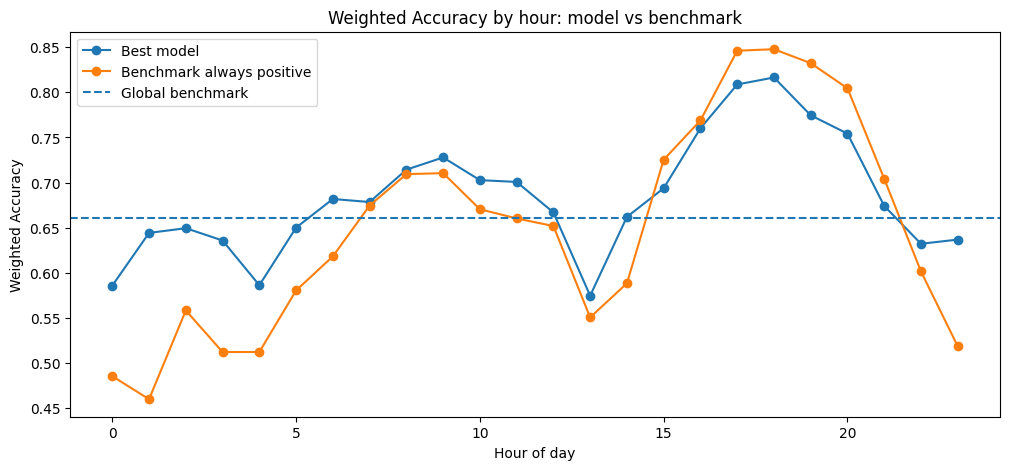

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_comparison["hour"],
    hourly_comparison["model_weighted_accuracy"],
    marker="o",
    label="Best model"
)

plt.plot(
    hourly_comparison["hour"],
    hourly_comparison["benchmark_weighted_accuracy"],
    marker="o",
    label="Benchmark always positive"
)

plt.axhline(
    benchmark_valid_weighted,
    linestyle="--",
    label="Global benchmark"
)

plt.title("Weighted Accuracy by hour: model vs benchmark")
plt.xlabel("Hour of day")
plt.ylabel("Weighted Accuracy")
plt.legend()
plt.show()

In [ ]:
display(
    hourly_comparison
    .sort_values("improvement_vs_benchmark", ascending=False)
)

,hour,model_weighted_accuracy,benchmark_weighted_accuracy,improvement_vs_benchmark,simple_accuracy,count
1,1,0.644217,0.460026,0.184192,0.586207,87
3,3,0.635800,0.512283,0.123517,0.597701,87
23,23,0.636822,0.518618,0.118204,0.569767,86
0,0,0.585859,0.485517,0.100341,0.551724,87
2,2,0.649443,0.558376,0.091067,0.574713,87
4,4,0.586291,0.512331,0.073960,0.551724,87
14,14,0.661961,0.588409,0.073553,0.540230,87
5,5,0.650060,0.580481,0.069578,0.632184,87
6,6,0.681784,0.618204,0.063580,0.586207,87
11,11,0.700683,0.660246,0.040438,0.574713,87


In [ ]:
print("Hours where model beats benchmark:")
display(hourly_comparison[hourly_comparison["improvement_vs_benchmark"] > 0])

print("Hours where model is below benchmark:")
display(hourly_comparison[hourly_comparison["improvement_vs_benchmark"] < 0])

Hours where model beats benchmark:


,hour,model_weighted_accuracy,benchmark_weighted_accuracy,improvement_vs_benchmark,simple_accuracy,count
0,0,0.585859,0.485517,0.100341,0.551724,87
1,1,0.644217,0.460026,0.184192,0.586207,87
2,2,0.649443,0.558376,0.091067,0.574713,87
3,3,0.635800,0.512283,0.123517,0.597701,87
4,4,0.586291,0.512331,0.073960,0.551724,87
5,5,0.650060,0.580481,0.069578,0.632184,87
6,6,0.681784,0.618204,0.063580,0.586207,87
7,7,0.678417,0.674501,0.003916,0.540230,87
8,8,0.714267,0.709301,0.004966,0.597701,87
9,9,0.727795,0.710420,0.017374,0.574713,87


Hours where model is below benchmark:


,hour,model_weighted_accuracy,benchmark_weighted_accuracy,improvement_vs_benchmark,simple_accuracy,count
15,15,0.693715,0.725326,-0.031611,0.586207,87
16,16,0.760064,0.768767,-0.008703,0.643678,87
17,17,0.808603,0.846014,-0.037411,0.655172,87
18,18,0.816357,0.847654,-0.031297,0.632184,87
19,19,0.774474,0.832218,-0.057743,0.609195,87
20,20,0.754181,0.804376,-0.050196,0.655172,87
21,21,0.674076,0.704131,-0.030055,0.632184,87


In [ ]:
display(hourly_comparison.sort_values("improvement_vs_benchmark", ascending=False))

print("Hours where model beats benchmark:")
display(hourly_comparison[hourly_comparison["improvement_vs_benchmark"] > 0])

print("Hours where model is below benchmark:")
display(hourly_comparison[hourly_comparison["improvement_vs_benchmark"] < 0])

,hour,model_weighted_accuracy,benchmark_weighted_accuracy,improvement_vs_benchmark,simple_accuracy,count
1,1,0.644217,0.460026,0.184192,0.586207,87
3,3,0.635800,0.512283,0.123517,0.597701,87
23,23,0.636822,0.518618,0.118204,0.569767,86
0,0,0.585859,0.485517,0.100341,0.551724,87
2,2,0.649443,0.558376,0.091067,0.574713,87
4,4,0.586291,0.512331,0.073960,0.551724,87
14,14,0.661961,0.588409,0.073553,0.540230,87
5,5,0.650060,0.580481,0.069578,0.632184,87
6,6,0.681784,0.618204,0.063580,0.586207,87
11,11,0.700683,0.660246,0.040438,0.574713,87


Hours where model beats benchmark:


,hour,model_weighted_accuracy,benchmark_weighted_accuracy,improvement_vs_benchmark,simple_accuracy,count
0,0,0.585859,0.485517,0.100341,0.551724,87
1,1,0.644217,0.460026,0.184192,0.586207,87
2,2,0.649443,0.558376,0.091067,0.574713,87
3,3,0.635800,0.512283,0.123517,0.597701,87
4,4,0.586291,0.512331,0.073960,0.551724,87
5,5,0.650060,0.580481,0.069578,0.632184,87
6,6,0.681784,0.618204,0.063580,0.586207,87
7,7,0.678417,0.674501,0.003916,0.540230,87
8,8,0.714267,0.709301,0.004966,0.597701,87
9,9,0.727795,0.710420,0.017374,0.574713,87


Hours where model is below benchmark:


,hour,model_weighted_accuracy,benchmark_weighted_accuracy,improvement_vs_benchmark,simple_accuracy,count
15,15,0.693715,0.725326,-0.031611,0.586207,87
16,16,0.760064,0.768767,-0.008703,0.643678,87
17,17,0.808603,0.846014,-0.037411,0.655172,87
18,18,0.816357,0.847654,-0.031297,0.632184,87
19,19,0.774474,0.832218,-0.057743,0.609195,87
20,20,0.754181,0.804376,-0.050196,0.655172,87
21,21,0.674076,0.704131,-0.030055,0.632184,87


In [ ]:
# Hours where benchmark is better than the model
benchmark_better_hours = hourly_comparison.loc[
    hourly_comparison["improvement_vs_benchmark"] < 0,
    "hour"
].tolist()

print("Hours where benchmark is better:", benchmark_better_hours)

Hours where benchmark is better: [15, 16, 17, 18, 19, 20, 21]


In [ ]:
### 6. Stratégie Hybride : Modèle + Benchmark par Heure
# Start from best model predictions
valid_analysis["hybrid_pred_class"] = valid_analysis["pred_class"].copy()

# For hours where benchmark is better, force positive prediction
valid_analysis.loc[
    valid_analysis["hour"].isin(benchmark_better_hours),
    "hybrid_pred_class"
] = 1

# Evaluation de la stratégie hybride
hybrid_pred_delta = np.where(valid_analysis["hybrid_pred_class"] == 1, 1, -1)
hybrid_weighted_accuracy = weighted_accuracy(valid_analysis["spot_id_delta"], hybrid_pred_delta)
print("Hybrid weighted accuracy:", round(hybrid_weighted_accuracy, 4))

Hybrid weighted accuracy: 0.7012


In [ ]:
cm_hybrid = confusion_matrix(
    valid_analysis["true_class"],
    valid_analysis["hybrid_pred_class"]
)

print("Hybrid confusion matrix:")
print(cm_hybrid)

print("\nHybrid classification report:")
print(classification_report(
    valid_analysis["true_class"],
    valid_analysis["hybrid_pred_class"]
))

Hybrid confusion matrix:
[[ 160  708]
 [ 129 1089]]

Hybrid classification report:
              precision    recall  f1-score   support

           0       0.55      0.18      0.28       868
           1       0.61      0.89      0.72      1218

    accuracy                           0.60      2086
   macro avg       0.58      0.54      0.50      2086
weighted avg       0.58      0.60      0.54      2086



In [ ]:
final_comparison = pd.DataFrame([
    {
        "strategy": "Benchmark always positive",
        "weighted_accuracy": benchmark_valid_weighted,
        "simple_accuracy": benchmark_valid_accuracy
    },
    {
        "strategy": "Best model only",
        "weighted_accuracy": best_valid_weighted,
        "simple_accuracy": best_valid_accuracy
    },
    {
        "strategy": "Hybrid: model + benchmark by hour",
        "weighted_accuracy": hybrid_weighted_accuracy,
        "simple_accuracy": hybrid_simple_accuracy
    }
])

display(final_comparison.sort_values("weighted_accuracy", ascending=False))

,strategy,weighted_accuracy,simple_accuracy
2,Hybrid: model + benchmark by hour,0.701245,0.598754
1,Best model only,0.690273,0.592522
0,Benchmark always positive,0.660402,0.583893


In [ ]:
print("Hours where benchmark is better:", benchmark_better_hours)

print("Best model weighted accuracy:", round(best_valid_weighted, 4))
print("Benchmark weighted accuracy:", round(benchmark_valid_weighted, 4))
print("Hybrid weighted accuracy:", round(hybrid_weighted_accuracy, 4))

print("Best model simple accuracy:", round(best_valid_accuracy, 4))
print("Hybrid simple accuracy:", round(hybrid_simple_accuracy, 4))

display(final_comparison.sort_values("weighted_accuracy", ascending=False))

Hours where benchmark is better: [15, 16, 17, 18, 19, 20, 21]
Best model weighted accuracy: 0.6903
Benchmark weighted accuracy: 0.6604
Hybrid weighted accuracy: 0.7012
Best model simple accuracy: 0.5925
Hybrid simple accuracy: 0.5988


,strategy,weighted_accuracy,simple_accuracy
2,Hybrid: model + benchmark by hour,0.701245,0.598754
1,Best model only,0.690273,0.592522
0,Benchmark always positive,0.660402,0.583893


In [ ]:
folds = [
    {
        "name": "Fold 1 - validation Jul-Sep 2022",
        "train_end": "2022-07-01",
        "valid_start": "2022-07-01",
        "valid_end": "2022-10-01"
    },
    {
        "name": "Fold 2 - validation Oct-Dec 2022",
        "train_end": "2022-10-01",
        "valid_start": "2022-10-01",
        "valid_end": "2023-01-01"
    },
    {
        "name": "Fold 3 - validation Jan-Mar 2023",
        "train_end": "2023-01-01",
        "valid_start": "2023-01-01",
        "valid_end": "2023-03-30"
    }
]

hybrid_benchmark_hours = [15, 16, 17, 18, 19, 20, 21]
fixed_threshold = 0.31

In [ ]:
def evaluate_time_fold(
    data,
    fold,
    feature_cols,
    fixed_threshold=0.31,
    hybrid_benchmark_hours=[15, 16, 17, 18, 19, 20, 21]
):
    train_end = pd.Timestamp(fold["train_end"], tz="UTC")
    valid_start = pd.Timestamp(fold["valid_start"], tz="UTC")
    valid_end = pd.Timestamp(fold["valid_end"], tz="UTC")

    train_fold = data[data["DELIVERY_START"] < train_end].copy()
    valid_fold = data[
        (data["DELIVERY_START"] >= valid_start)
        & (data["DELIVERY_START"] < valid_end)
    ].copy()

    X_train_fold = train_fold[feature_cols]
    y_train_class_fold = train_fold["target_direction"]
    y_train_delta_fold = train_fold["spot_id_delta"]

    X_valid_fold = valid_fold[feature_cols]
    y_valid_class_fold = valid_fold["target_direction"]
    y_valid_delta_fold = valid_fold["spot_id_delta"]

    # Capped sample weights
    sample_weights_fold = np.abs(y_train_delta_fold)
    cap_95_fold = sample_weights_fold.quantile(0.95)
    sample_weights_fold_capped = sample_weights_fold.clip(upper=cap_95_fold)

    # Model
    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ])

    model.fit(
        X_train_fold,
        y_train_class_fold,
        model__sample_weight=sample_weights_fold_capped
    )

    # Probabilities
    valid_proba = model.predict_proba(X_valid_fold)[:, 1]

    # Model-only predictions
    pred_class_model = (valid_proba >= fixed_threshold).astype(int)
    pred_delta_model = np.where(pred_class_model == 1, 1, -1)

    model_weighted = weighted_accuracy(
        y_true=y_valid_delta_fold,
        y_pred=pred_delta_model
    )

    model_simple = accuracy_score(
        y_valid_class_fold,
        pred_class_model
    )

    # Benchmark always positive
    pred_delta_benchmark = np.ones(len(valid_fold))

    benchmark_weighted = weighted_accuracy(
        y_true=y_valid_delta_fold,
        y_pred=pred_delta_benchmark
    )

    benchmark_simple = ((y_valid_delta_fold > 0) == True).mean()

    # Hybrid predictions
    pred_class_hybrid = pred_class_model.copy()

    hours = valid_fold["hour"].values
    pred_class_hybrid[np.isin(hours, hybrid_benchmark_hours)] = 1

    pred_delta_hybrid = np.where(pred_class_hybrid == 1, 1, -1)

    hybrid_weighted = weighted_accuracy(
        y_true=y_valid_delta_fold,
        y_pred=pred_delta_hybrid
    )

    hybrid_simple = accuracy_score(
        y_valid_class_fold,
        pred_class_hybrid
    )

    return {
        "fold": fold["name"],
        "train_rows": len(train_fold),
        "valid_rows": len(valid_fold),
        "cap_95": cap_95_fold,
        "benchmark_weighted": benchmark_weighted,
        "model_weighted": model_weighted,
        "hybrid_weighted": hybrid_weighted,
        "benchmark_simple": benchmark_simple,
        "model_simple": model_simple,
        "hybrid_simple": hybrid_simple,
        "model_vs_benchmark": model_weighted - benchmark_weighted,
        "hybrid_vs_benchmark": hybrid_weighted - benchmark_weighted
    }

In [ ]:
### 7. Backtesting Temporel (Time-based Cross-Validation)
backtest_results = []

for fold in folds:
    result = evaluate_time_fold(
        data=df_features,
        fold=fold,
        feature_cols=feature_cols,
        fixed_threshold=fixed_threshold,
        hybrid_benchmark_hours=hybrid_benchmark_hours
    )
    backtest_results.append(result)

backtest_results = pd.DataFrame(backtest_results)
display(backtest_results)

,fold,train_rows,valid_rows,cap_95,benchmark_weighted,model_weighted,hybrid_weighted,benchmark_simple,model_simple,hybrid_simple,model_vs_benchmark,hybrid_vs_benchmark
0,Fold 1 - validation Jul-Sep 2022,4176,2136,38.863328,0.501447,0.417700,0.452351,0.465824,0.454588,0.448502,-0.083747,-0.049096
1,Fold 2 - validation Oct-Dec 2022,6312,2207,70.480092,0.546801,0.461545,0.485862,0.506570,0.497055,0.492071,-0.085256,-0.060940
2,Fold 3 - validation Jan-Mar 2023,8519,2086,64.872064,0.660402,0.690273,0.701245,0.583893,0.592522,0.598754,0.029871,0.040843


In [ ]:
summary_cols = [
    "benchmark_weighted",
    "model_weighted",
    "hybrid_weighted",
    "benchmark_simple",
    "model_simple",
    "hybrid_simple",
    "model_vs_benchmark",
    "hybrid_vs_benchmark"
]

display(backtest_results[summary_cols].mean().to_frame("average_score"))

,average_score
benchmark_weighted,0.569550
model_weighted,0.523172
hybrid_weighted,0.546486
benchmark_simple,0.518762
model_simple,0.514721
hybrid_simple,0.513109
model_vs_benchmark,-0.046378
hybrid_vs_benchmark,-0.023064


In [ ]:
display(backtest_results)

display(backtest_results[summary_cols].mean().to_frame("average_score"))

,fold,train_rows,valid_rows,cap_95,benchmark_weighted,model_weighted,hybrid_weighted,benchmark_simple,model_simple,hybrid_simple,model_vs_benchmark,hybrid_vs_benchmark
0,Fold 1 - validation Jul-Sep 2022,4176,2136,38.863328,0.501447,0.417700,0.452351,0.465824,0.454588,0.448502,-0.083747,-0.049096
1,Fold 2 - validation Oct-Dec 2022,6312,2207,70.480092,0.546801,0.461545,0.485862,0.506570,0.497055,0.492071,-0.085256,-0.060940
2,Fold 3 - validation Jan-Mar 2023,8519,2086,64.872064,0.660402,0.690273,0.701245,0.583893,0.592522,0.598754,0.029871,0.040843


,average_score
benchmark_weighted,0.569550
model_weighted,0.523172
hybrid_weighted,0.546486
benchmark_simple,0.518762
model_simple,0.514721
hybrid_simple,0.513109
model_vs_benchmark,-0.046378
hybrid_vs_benchmark,-0.023064


In [ ]:
df_features["year_month"] = df_features["DELIVERY_START"].dt.to_period("M")

monthly_benchmark = []

for month, group in df_features.groupby("year_month"):
    y_true_month = group["spot_id_delta"]
    y_pred_month = np.ones(len(group))

    weighted_score = weighted_accuracy(
        y_true=y_true_month,
        y_pred=y_pred_month
    )

    simple_score = ((y_true_month > 0) == True).mean()

    monthly_benchmark.append({
        "month": str(month),
        "rows": len(group),
        "benchmark_weighted_accuracy": weighted_score,
        "benchmark_simple_accuracy": simple_score,
        "share_positive": (y_true_month > 0).mean(),
        "mean_delta": y_true_month.mean(),
        "median_delta": y_true_month.median(),
        "mean_abs_delta": y_true_month.abs().mean()
    })

monthly_benchmark = pd.DataFrame(monthly_benchmark)

display(monthly_benchmark)

/tmp/ipykernel_4165/4204421228.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_features["year_month"] = df_features["DELIVERY_START"].dt.to_period("M")


,month,rows,benchmark_weighted_accuracy,benchmark_simple_accuracy,share_positive,mean_delta,median_delta,mean_abs_delta
0,2022-01,743,0.635866,0.522207,0.522207,3.992867,1.008021,14.694143
1,2022-02,633,0.299293,0.314376,0.314376,-4.802887,-5.705033,11.964944
2,2022-03,695,0.384356,0.448921,0.448921,-3.767562,-1.873104,16.289435
3,2022-04,713,0.321506,0.389902,0.389902,-6.532905,-3.726645,18.300037
4,2022-05,720,0.570575,0.543056,0.543056,1.255550,1.089781,8.895161
5,2022-06,672,0.719444,0.626488,0.626488,6.431499,5.094981,14.654068
6,2022-07,744,0.598979,0.502688,0.502688,6.937859,0.535700,35.046953
7,2022-08,744,0.492042,0.463710,0.463710,-0.563060,-2.628357,35.374851
8,2022-09,648,0.417834,0.425926,0.425926,-6.962536,-10.230271,42.368606
9,2022-10,743,0.510985,0.462988,0.462988,0.454653,-2.131751,20.693882


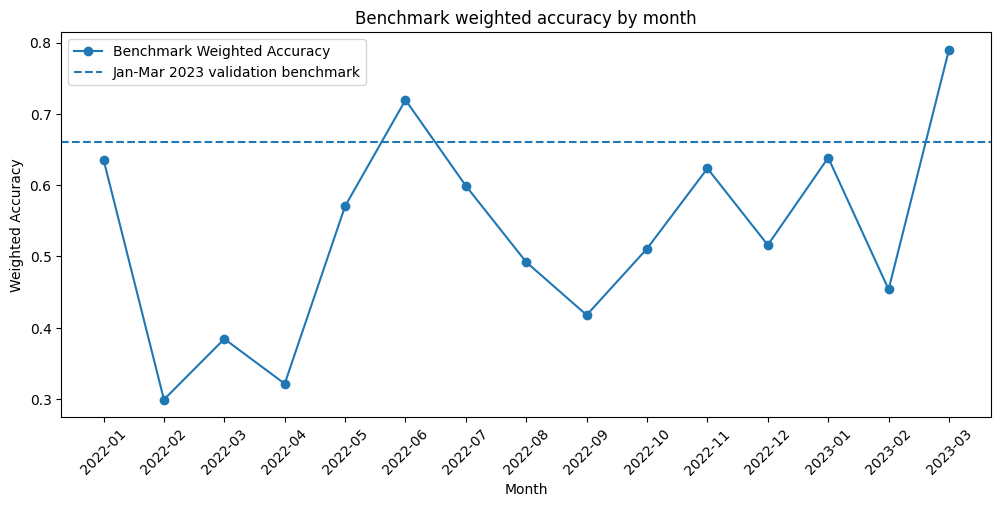

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(
    monthly_benchmark["month"],
    monthly_benchmark["benchmark_weighted_accuracy"],
    marker="o",
    label="Benchmark Weighted Accuracy"
)

plt.axhline(
    benchmark_valid_weighted,
    linestyle="--",
    label="Jan-Mar 2023 validation benchmark"
)

plt.title("Benchmark weighted accuracy by month")
plt.xlabel("Month")
plt.ylabel("Weighted Accuracy")
plt.xticks(rotation=45)
plt.legend()
plt.show()

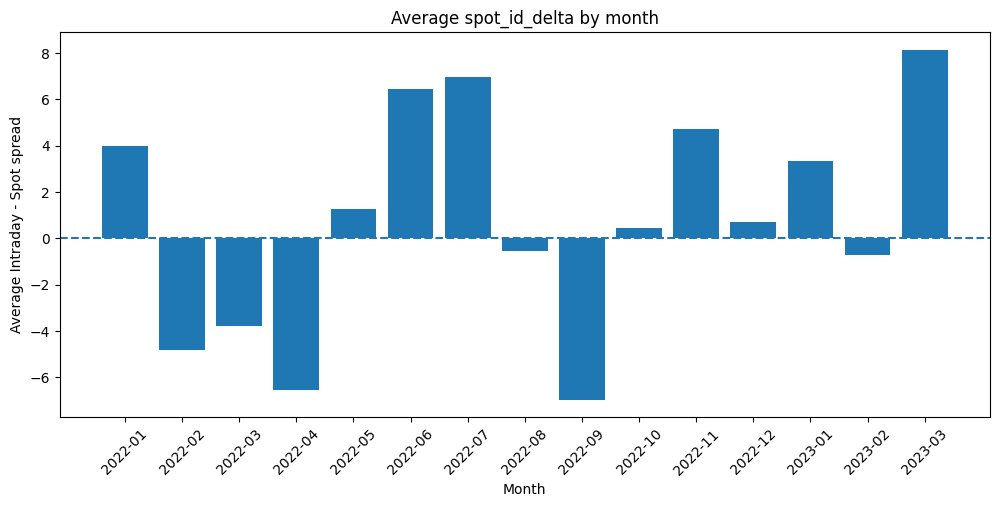

In [ ]:
plt.figure(figsize=(12, 5))
plt.bar(
    monthly_benchmark["month"],
    monthly_benchmark["mean_delta"]
)

plt.axhline(0, linestyle="--")
plt.title("Average spot_id_delta by month")
plt.xlabel("Month")
plt.ylabel("Average Intraday - Spot spread")
plt.xticks(rotation=45)
plt.show()

In [ ]:
display(monthly_benchmark)

,month,rows,benchmark_weighted_accuracy,benchmark_simple_accuracy,share_positive,mean_delta,median_delta,mean_abs_delta
0,2022-01,743,0.635866,0.522207,0.522207,3.992867,1.008021,14.694143
1,2022-02,633,0.299293,0.314376,0.314376,-4.802887,-5.705033,11.964944
2,2022-03,695,0.384356,0.448921,0.448921,-3.767562,-1.873104,16.289435
3,2022-04,713,0.321506,0.389902,0.389902,-6.532905,-3.726645,18.300037
4,2022-05,720,0.570575,0.543056,0.543056,1.255550,1.089781,8.895161
5,2022-06,672,0.719444,0.626488,0.626488,6.431499,5.094981,14.654068
6,2022-07,744,0.598979,0.502688,0.502688,6.937859,0.535700,35.046953
7,2022-08,744,0.492042,0.463710,0.463710,-0.563060,-2.628357,35.374851
8,2022-09,648,0.417834,0.425926,0.425926,-6.962536,-10.230271,42.368606
9,2022-10,743,0.510985,0.462988,0.462988,0.454653,-2.131751,20.693882


In [ ]:
def train_evaluate_window(
    data,
    train_start,
    train_end,
    valid_start,
    valid_end,
    feature_cols,
    threshold_grid=np.arange(0.05, 0.96, 0.01),
    hybrid_hours=[15, 16, 17, 18, 19, 20, 21]
):
    train_start = pd.Timestamp(train_start, tz="UTC") if train_start is not None else data["DELIVERY_START"].min()
    train_end = pd.Timestamp(train_end, tz="UTC")
    valid_start = pd.Timestamp(valid_start, tz="UTC")
    valid_end = pd.Timestamp(valid_end, tz="UTC")

    train_window = data[
        (data["DELIVERY_START"] >= train_start)
        & (data["DELIVERY_START"] < train_end)
    ].copy()

    valid_window = data[
        (data["DELIVERY_START"] >= valid_start)
        & (data["DELIVERY_START"] < valid_end)
    ].copy()

    X_train_w = train_window[feature_cols]
    y_train_class_w = train_window["target_direction"]
    y_train_delta_w = train_window["spot_id_delta"]

    X_valid_w = valid_window[feature_cols]
    y_valid_class_w = valid_window["target_direction"]
    y_valid_delta_w = valid_window["spot_id_delta"]

    # Capped sample weights
    weights = np.abs(y_train_delta_w)
    cap_95 = weights.quantile(0.95)
    weights_capped = weights.clip(upper=cap_95)

    model = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ])

    model.fit(
        X_train_w,
        y_train_class_w,
        model__sample_weight=weights_capped
    )

    proba_valid = model.predict_proba(X_valid_w)[:, 1]

    # Search best threshold
    threshold_scores = []

    for threshold in threshold_grid:
        pred_class = (proba_valid >= threshold).astype(int)
        pred_delta = np.where(pred_class == 1, 1, -1)

        score = weighted_accuracy(y_valid_delta_w, pred_delta)
        simple_acc = accuracy_score(y_valid_class_w, pred_class)

        threshold_scores.append({
            "threshold": threshold,
            "weighted_accuracy": score,
            "simple_accuracy": simple_acc,
            "positive_predictions": pred_class.sum()
        })

    threshold_scores = pd.DataFrame(threshold_scores)
    best_row = threshold_scores.sort_values("weighted_accuracy", ascending=False).iloc[0]

    best_threshold = best_row["threshold"]
    best_pred_class = (proba_valid >= best_threshold).astype(int)
    best_pred_delta = np.where(best_pred_class == 1, 1, -1)

    # Benchmark
    benchmark_pred_delta = np.ones(len(valid_window))
    benchmark_score = weighted_accuracy(y_valid_delta_w, benchmark_pred_delta)
    benchmark_simple = ((y_valid_delta_w > 0) == True).mean()

    # Hybrid: force positive on selected hours
    hybrid_pred_class = best_pred_class.copy()
    hours = valid_window["hour"].values
    hybrid_pred_class[np.isin(hours, hybrid_hours)] = 1
    hybrid_pred_delta = np.where(hybrid_pred_class == 1, 1, -1)

    hybrid_score = weighted_accuracy(y_valid_delta_w, hybrid_pred_delta)
    hybrid_simple = accuracy_score(y_valid_class_w, hybrid_pred_class)

    return {
        "train_start": str(train_start.date()),
        "train_end": str(train_end.date()),
        "train_rows": len(train_window),
        "valid_rows": len(valid_window),
        "cap_95": cap_95,
        "best_threshold": best_threshold,
        "model_weighted_accuracy": best_row["weighted_accuracy"],
        "model_simple_accuracy": best_row["simple_accuracy"],
        "model_positive_predictions": best_row["positive_predictions"],
        "hybrid_weighted_accuracy": hybrid_score,
        "hybrid_simple_accuracy": hybrid_simple,
        "benchmark_weighted_accuracy": benchmark_score,
        "benchmark_simple_accuracy": benchmark_simple,
        "model_vs_benchmark": best_row["weighted_accuracy"] - benchmark_score,
        "hybrid_vs_benchmark": hybrid_score - benchmark_score
    }

In [ ]:
training_windows = [
    {
        "name": "All history before Jan 2023",
        "train_start": None,
        "train_end": "2023-01-01"
    },
    {
        "name": "Since Jul 2022",
        "train_start": "2022-07-01",
        "train_end": "2023-01-01"
    },
    {
        "name": "Since Sep 2022",
        "train_start": "2022-09-01",
        "train_end": "2023-01-01"
    },
    {
        "name": "Since Oct 2022",
        "train_start": "2022-10-01",
        "train_end": "2023-01-01"
    },
    {
        "name": "Since Nov 2022",
        "train_start": "2022-11-01",
        "train_end": "2023-01-01"
    }
]

window_results = []

for window in training_windows:
    result = train_evaluate_window(
        data=df_features,
        train_start=window["train_start"],
        train_end=window["train_end"],
        valid_start="2023-01-01",
        valid_end="2023-03-30",
        feature_cols=feature_cols
    )

    result["window_name"] = window["name"]
    window_results.append(result)

window_results = pd.DataFrame(window_results)

display(
    window_results[
        [
            "window_name",
            "train_rows",
            "best_threshold",
            "benchmark_weighted_accuracy",
            "model_weighted_accuracy",
            "hybrid_weighted_accuracy",
            "model_vs_benchmark",
            "hybrid_vs_benchmark",
            "model_simple_accuracy",
            "hybrid_simple_accuracy"
        ]
    ].sort_values("hybrid_weighted_accuracy", ascending=False)
)

,window_name,train_rows,best_threshold,benchmark_weighted_accuracy,model_weighted_accuracy,hybrid_weighted_accuracy,model_vs_benchmark,hybrid_vs_benchmark,model_simple_accuracy,hybrid_simple_accuracy
0,All history before Jan 2023,8519,0.31,0.660402,0.690273,0.701245,0.029871,0.040843,0.592522,0.598754
1,Since Jul 2022,4343,0.05,0.660402,0.660402,0.660402,0.000000,0.000000,0.583893,0.583893
2,Since Sep 2022,2855,0.05,0.660402,0.660402,0.660402,0.000000,0.000000,0.583893,0.583893
4,Since Nov 2022,1464,0.05,0.660402,0.660402,0.660402,0.000000,0.000000,0.583893,0.583893
3,Since Oct 2022,2207,0.05,0.660402,0.590210,0.634830,-0.070192,-0.025572,0.543145,0.569032


In [ ]:
# Final training data: all available training set
X_final_train = df_features[feature_cols]
y_final_class = df_features["target_direction"]
y_final_delta = df_features["spot_id_delta"]

# Capped sample weights on full training data
final_weights = np.abs(y_final_delta)
final_cap_95 = final_weights.quantile(0.95)
final_weights_capped = final_weights.clip(upper=final_cap_95)

print("Final training shape:", X_final_train.shape)
print("Final cap 95:", final_cap_95)

Final training shape: (10605, 27)
Final cap 95: 59.59074262300479


In [ ]:
final_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

final_model.fit(
    X_final_train,
    y_final_class,
    model__sample_weight=final_weights_capped
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
X_final_test = X_test_features[feature_cols]

print("X_final_test shape:", X_final_test.shape)
print("Same columns:", list(X_final_test.columns) == list(X_final_train.columns))

X_final_test shape: (4942, 27)
Same columns: True


In [ ]:
final_threshold = 0.31

test_proba_positive = final_model.predict_proba(X_final_test)[:, 1]
test_pred_class = (test_proba_positive >= final_threshold).astype(int)

print("Positive predictions before hybrid:", test_pred_class.sum())
print("Negative predictions before hybrid:", len(test_pred_class) - test_pred_class.sum())

Positive predictions before hybrid: 2283
Negative predictions before hybrid: 2659


In [ ]:
hybrid_hours = [15, 16, 17, 18, 19, 20, 21]

test_pred_class_hybrid = test_pred_class.copy()

test_hours = X_test_features["hour"].values

test_pred_class_hybrid[np.isin(test_hours, hybrid_hours)] = 1

print("Positive predictions after hybrid:", test_pred_class_hybrid.sum())
print("Negative predictions after hybrid:", len(test_pred_class_hybrid) - test_pred_class_hybrid.sum())

Positive predictions after hybrid: 2908
Negative predictions after hybrid: 2034


In [ ]:
test_pred_delta_hybrid = np.where(
    test_pred_class_hybrid == 1,
    1,
    -1
)

In [ ]:
submission = pd.DataFrame({
    "DELIVERY_START": X_test_features["DELIVERY_START"],
    "spot_id_delta": test_pred_delta_hybrid
})

display(submission.head())
display(submission.tail())

print(submission.shape)
print(submission["spot_id_delta"].value_counts())

,DELIVERY_START,spot_id_delta
0,2023-04-01 22:00:00+00:00,1
1,2023-04-01 23:00:00+00:00,1
2,2023-04-02 00:00:00+00:00,1
3,2023-04-02 01:00:00+00:00,1
4,2023-04-02 02:00:00+00:00,1


,DELIVERY_START,spot_id_delta
4937,2023-10-24 17:00:00+00:00,1
4938,2023-10-24 18:00:00+00:00,1
4939,2023-10-24 19:00:00+00:00,1
4940,2023-10-24 20:00:00+00:00,1
4941,2023-10-24 21:00:00+00:00,1


(4942, 2)
spot_id_delta
 1    2908
-1    2034
Name: count, dtype: int64


In [ ]:
print("Final training shape:", X_final_train.shape)
print("Final cap 95:", final_cap_95)
print("Same columns:", list(X_final_test.columns) == list(X_final_train.columns))

print("Positive predictions before hybrid:", test_pred_class.sum())
print("Negative predictions before hybrid:", len(test_pred_class) - test_pred_class.sum())

print("Positive predictions after hybrid:", test_pred_class_hybrid.sum())
print("Negative predictions after hybrid:", len(test_pred_class_hybrid) - test_pred_class_hybrid.sum())

print(submission.shape)
print(submission["spot_id_delta"].value_counts())

Final training shape: (10605, 27)
Final cap 95: 59.59074262300479
Same columns: True
Positive predictions before hybrid: 2283
Negative predictions before hybrid: 2659
Positive predictions after hybrid: 2908
Negative predictions after hybrid: 2034
(4942, 2)
spot_id_delta
 1    2908
-1    2034
Name: count, dtype: int64


In [ ]:
### 8. Génération du Fichier de Soumission
submission = pd.DataFrame({
    "DELIVERY_START": X_test_features["DELIVERY_START"].dt.tz_convert("Europe/Paris").astype(str),
    "spot_id_delta": test_pred_delta_hybrid
})

display(submission.head())
print("Submission shape:", submission.shape)

,DELIVERY_START,spot_id_delta
0,2023-04-02 00:00:00+02:00,1
1,2023-04-02 01:00:00+02:00,1
2,2023-04-02 02:00:00+02:00,1
3,2023-04-02 03:00:00+02:00,1
4,2023-04-02 04:00:00+02:00,1


Submission shape: (4942, 2)


In [ ]:
print(submission.columns.tolist())
print(submission.dtypes)
display(submission.head(10))

['DELIVERY_START', 'spot_id_delta']
DELIVERY_START    object
spot_id_delta      int64
dtype: object


,DELIVERY_START,spot_id_delta
0,2023-04-02 00:00:00+02:00,1
1,2023-04-02 01:00:00+02:00,1
2,2023-04-02 02:00:00+02:00,1
3,2023-04-02 03:00:00+02:00,1
4,2023-04-02 04:00:00+02:00,1
5,2023-04-02 05:00:00+02:00,1
6,2023-04-02 06:00:00+02:00,1
7,2023-04-02 07:00:00+02:00,1
8,2023-04-02 08:00:00+02:00,1
9,2023-04-02 09:00:00+02:00,1


Recapitulatif Global

PROJECT 140 — ELECTRICITY PRICES PREDICTION
Final recap of methodology, results and model interpretation

1. DATASET OVERVIEW
--------------------------------------------------------------------------------
Train period: 2022-01-01 01:00:00+00:00 to 2023-03-29 21:00:00+00:00
Number of training rows: 10605
Number of explanatory features used: 27
Test period: 2023-04-01 22:00:00+00:00 to 2023-10-24 21:00:00+00:00
Number of test rows: 4942


,spot_id_delta
count,10605.000000
mean,0.943358
std,38.093819
min,-1567.353547
25%,-11.934152
50%,0.059125
75%,12.190489
max,658.961329


Share of positive spreads: 0.5017
Share of negative spreads: 0.4983


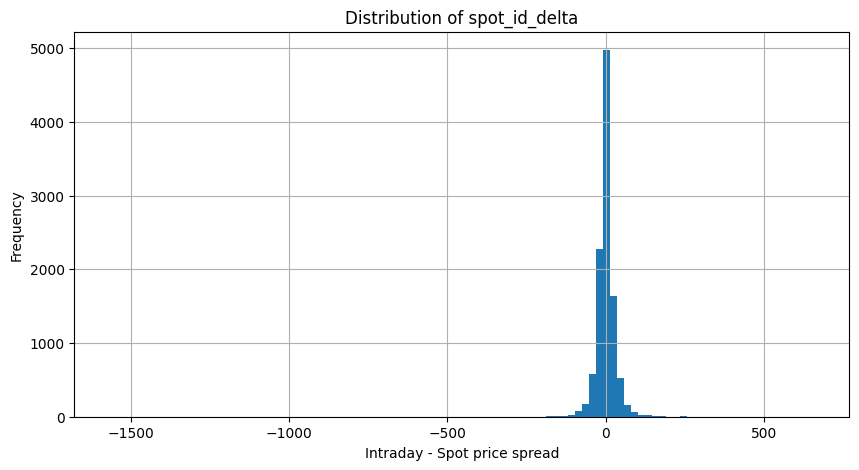

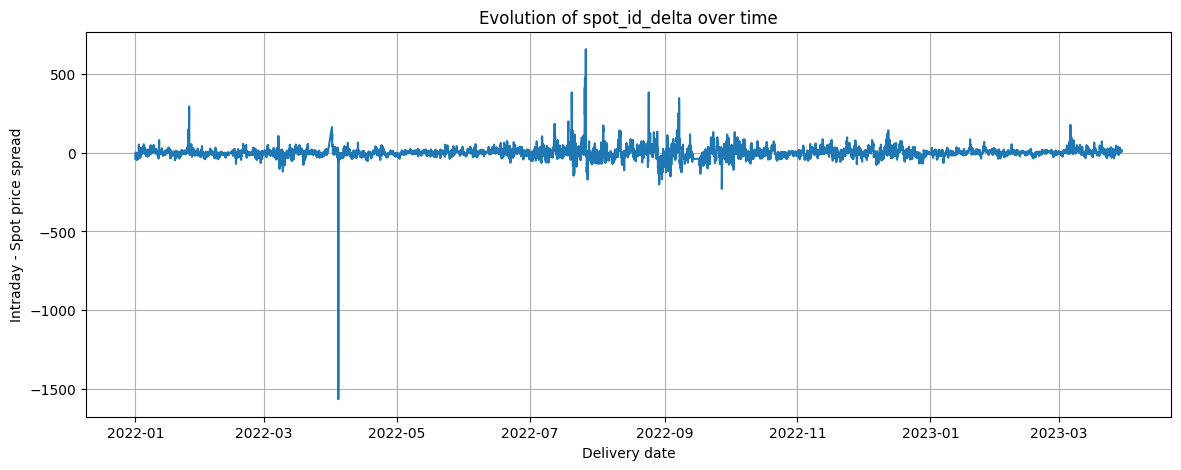


2. MODEL COMPARISON
--------------------------------------------------------------------------------


,model,best_threshold,weighted_accuracy
5,Capped Weighted Logistic Regression,0.31,0.690273
4,Weighted Logistic Regression,0.32,0.688332
1,Logistic Regression,0.35,0.683309
2,Random Forest,0.33,0.672068
3,HistGradientBoosting,0.16,0.666757
0,Benchmark always positive,NaN,0.660402


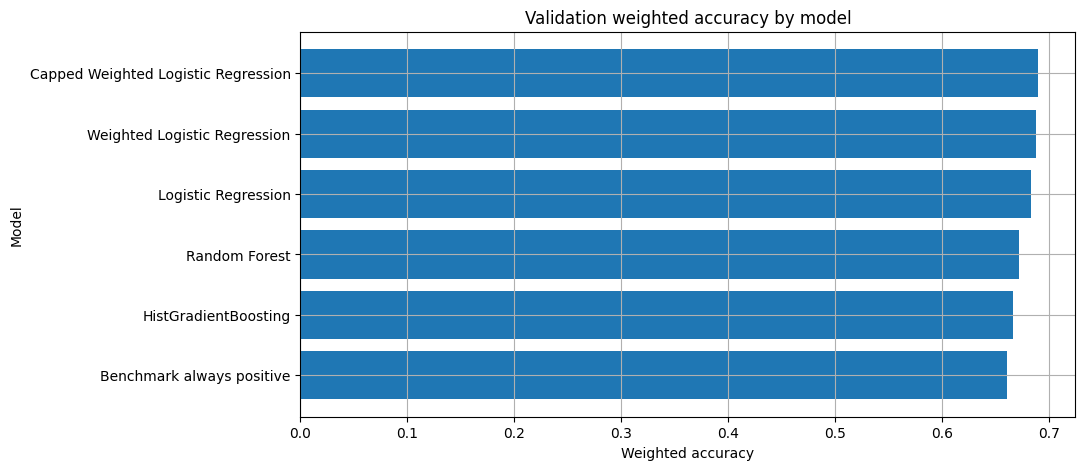


3. FINAL STRATEGY COMPARISON
--------------------------------------------------------------------------------


,strategy,weighted_accuracy,simple_accuracy
2,Hybrid: model + benchmark by hour,0.701245,0.598754
1,Best model only,0.690273,0.592522
0,Benchmark always positive,0.660402,0.583893


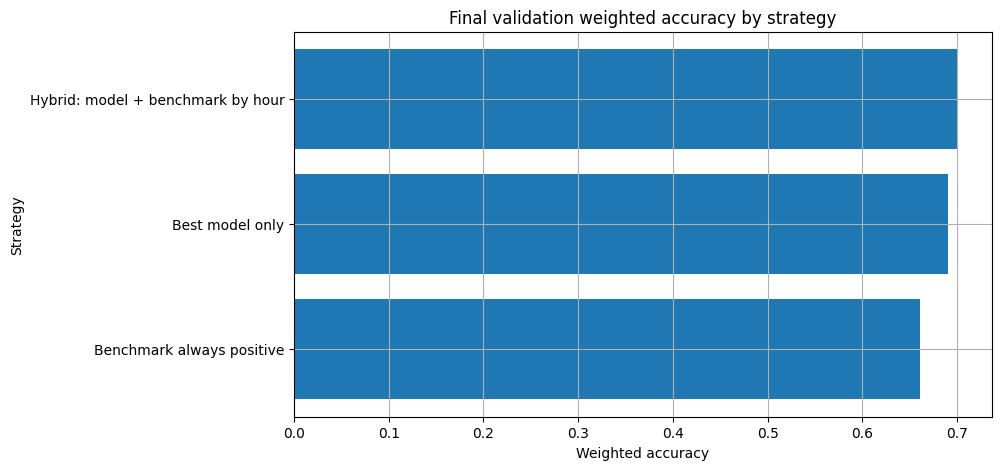


4. BEST MODEL PERFORMANCE ON VALIDATION SET
--------------------------------------------------------------------------------
Best model simple accuracy: 0.5925
Best model weighted accuracy: 0.6903
Hybrid strategy weighted accuracy: 0.7012
Benchmark weighted accuracy: 0.6604

Best model classification report:
              precision    recall  f1-score   support

           0       0.53      0.21      0.30       868
           1       0.61      0.86      0.71      1218

    accuracy                           0.59      2086
   macro avg       0.57      0.54      0.51      2086
weighted avg       0.57      0.59      0.54      2086



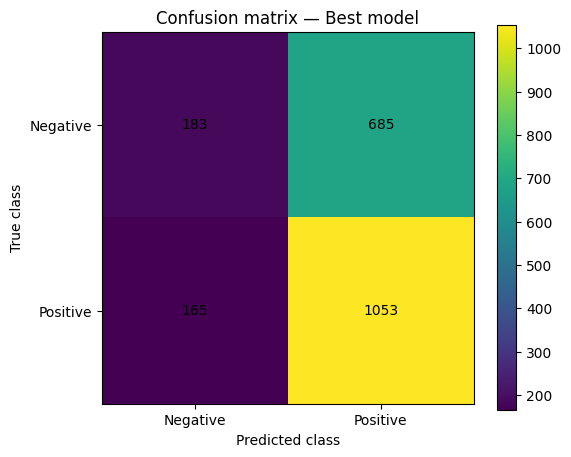


5. HYBRID STRATEGY PERFORMANCE
--------------------------------------------------------------------------------
Hybrid classification report:
              precision    recall  f1-score   support

           0       0.55      0.18      0.28       868
           1       0.61      0.89      0.72      1218

    accuracy                           0.60      2086
   macro avg       0.58      0.54      0.50      2086
weighted avg       0.58      0.60      0.54      2086



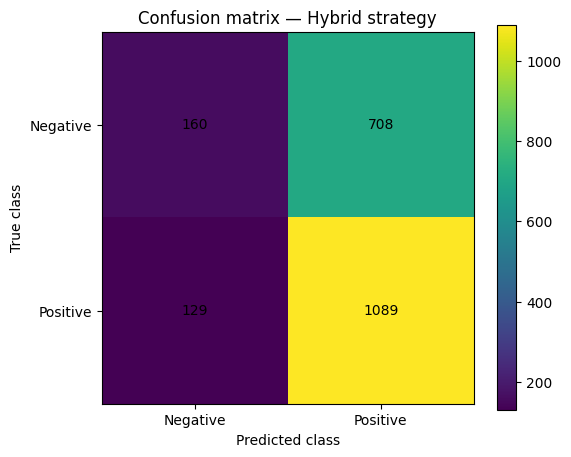


6. HOURLY PERFORMANCE ANALYSIS
--------------------------------------------------------------------------------


,hour,model_weighted_accuracy,benchmark_weighted_accuracy,improvement_vs_benchmark,simple_accuracy,count
0,0,0.585859,0.485517,0.100341,0.551724,87
1,1,0.644217,0.460026,0.184192,0.586207,87
2,2,0.649443,0.558376,0.091067,0.574713,87
3,3,0.635800,0.512283,0.123517,0.597701,87
4,4,0.586291,0.512331,0.073960,0.551724,87
5,5,0.650060,0.580481,0.069578,0.632184,87
6,6,0.681784,0.618204,0.063580,0.586207,87
7,7,0.678417,0.674501,0.003916,0.540230,87
8,8,0.714267,0.709301,0.004966,0.597701,87
9,9,0.727795,0.710420,0.017374,0.574713,87


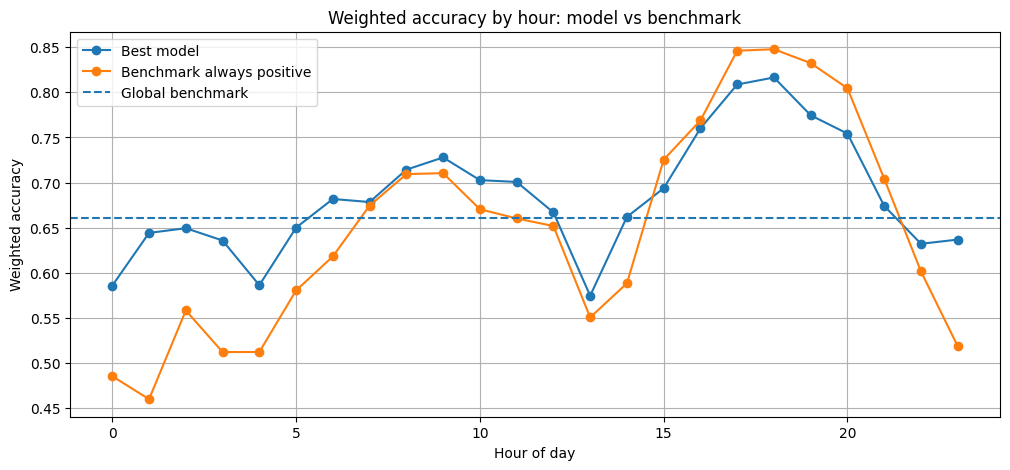

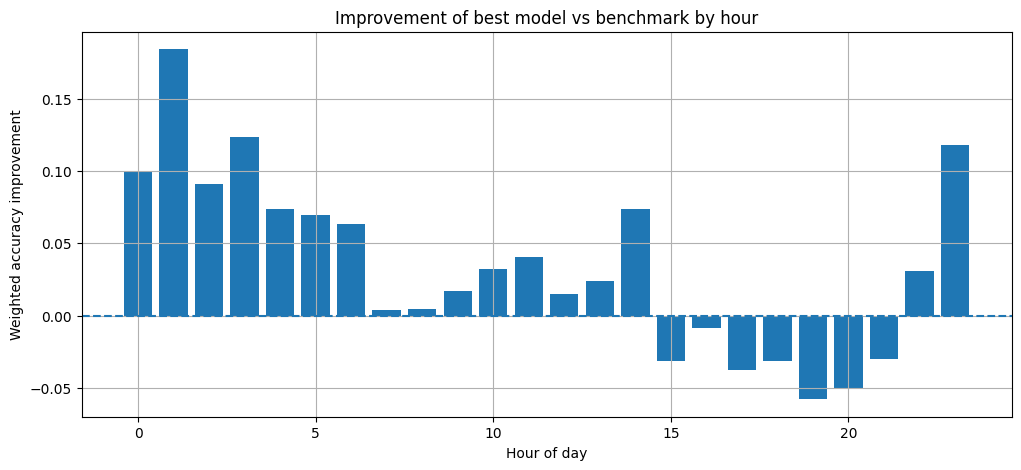


7. MONTHLY REGIME ANALYSIS
--------------------------------------------------------------------------------


,month,rows,benchmark_weighted_accuracy,benchmark_simple_accuracy,share_positive,mean_delta,median_delta,mean_abs_delta
0,2022-01,743,0.635866,0.522207,0.522207,3.992867,1.008021,14.694143
1,2022-02,633,0.299293,0.314376,0.314376,-4.802887,-5.705033,11.964944
2,2022-03,695,0.384356,0.448921,0.448921,-3.767562,-1.873104,16.289435
3,2022-04,713,0.321506,0.389902,0.389902,-6.532905,-3.726645,18.300037
4,2022-05,720,0.570575,0.543056,0.543056,1.255550,1.089781,8.895161
5,2022-06,672,0.719444,0.626488,0.626488,6.431499,5.094981,14.654068
6,2022-07,744,0.598979,0.502688,0.502688,6.937859,0.535700,35.046953
7,2022-08,744,0.492042,0.463710,0.463710,-0.563060,-2.628357,35.374851
8,2022-09,648,0.417834,0.425926,0.425926,-6.962536,-10.230271,42.368606
9,2022-10,743,0.510985,0.462988,0.462988,0.454653,-2.131751,20.693882


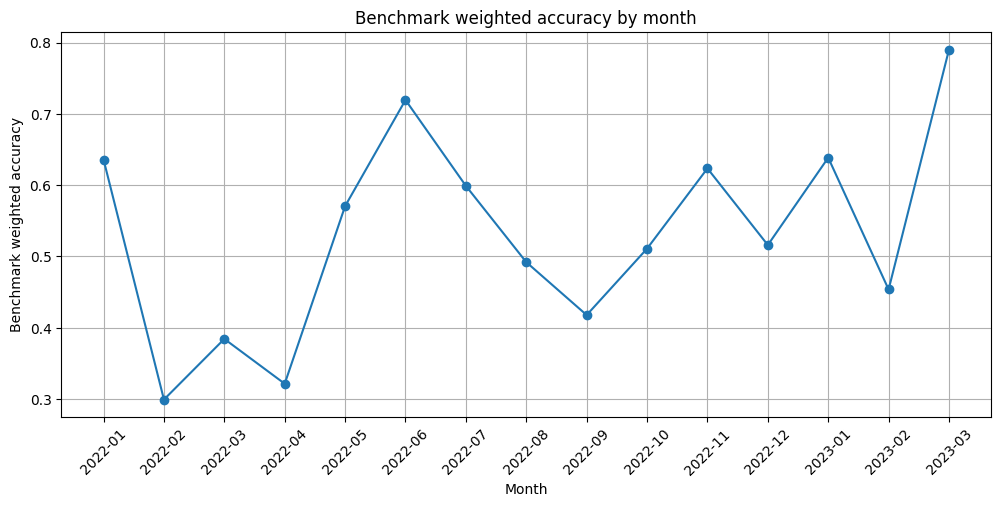

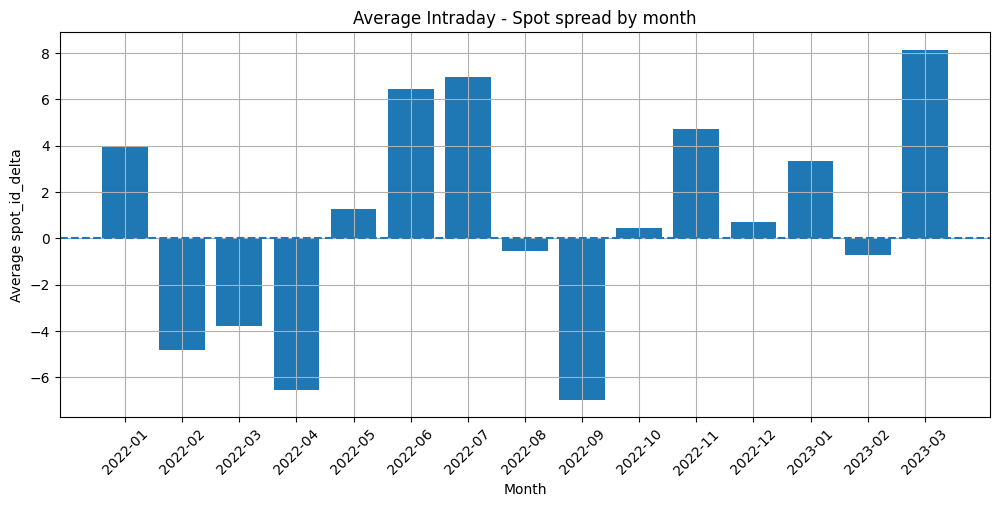


8. TIME-BASED BACKTEST RESULTS
--------------------------------------------------------------------------------


,fold,train_rows,valid_rows,cap_95,benchmark_weighted,model_weighted,hybrid_weighted,benchmark_simple,model_simple,hybrid_simple,model_vs_benchmark,hybrid_vs_benchmark
0,Fold 1 - validation Jul-Sep 2022,4176,2136,38.863328,0.501447,0.417700,0.452351,0.465824,0.454588,0.448502,-0.083747,-0.049096
1,Fold 2 - validation Oct-Dec 2022,6312,2207,70.480092,0.546801,0.461545,0.485862,0.506570,0.497055,0.492071,-0.085256,-0.060940
2,Fold 3 - validation Jan-Mar 2023,8519,2086,64.872064,0.660402,0.690273,0.701245,0.583893,0.592522,0.598754,0.029871,0.040843


,average_score
benchmark_weighted,0.569550
model_weighted,0.523172
hybrid_weighted,0.546486
benchmark_simple,0.518762
model_simple,0.514721
hybrid_simple,0.513109
model_vs_benchmark,-0.046378
hybrid_vs_benchmark,-0.023064


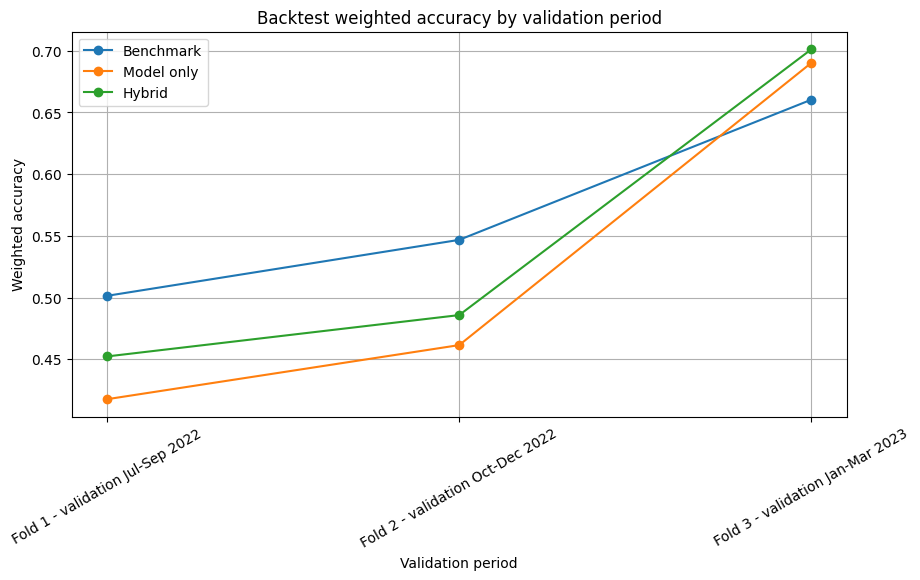


9. FEATURE INTERPRETATION
--------------------------------------------------------------------------------
Top coefficients of the final logistic regression model:


,feature,coefficient,abs_coefficient
0,load_forecast,1.890325,1.890325
20,residual_load,-1.579836,1.579836
19,renewable_forecast,-1.511807,1.511807
4,wind_power_forecasts_average,1.213833,1.213833
5,solar_power_forecasts_average,0.772384,0.772384
24,renewable_uncertainty,-0.570422,0.570422
6,wind_power_forecasts_std,0.430988,0.430988
2,gas_power_available,-0.411819,0.411819
23,renewable_share,-0.365103,0.365103
7,solar_power_forecasts_std,0.307758,0.307758


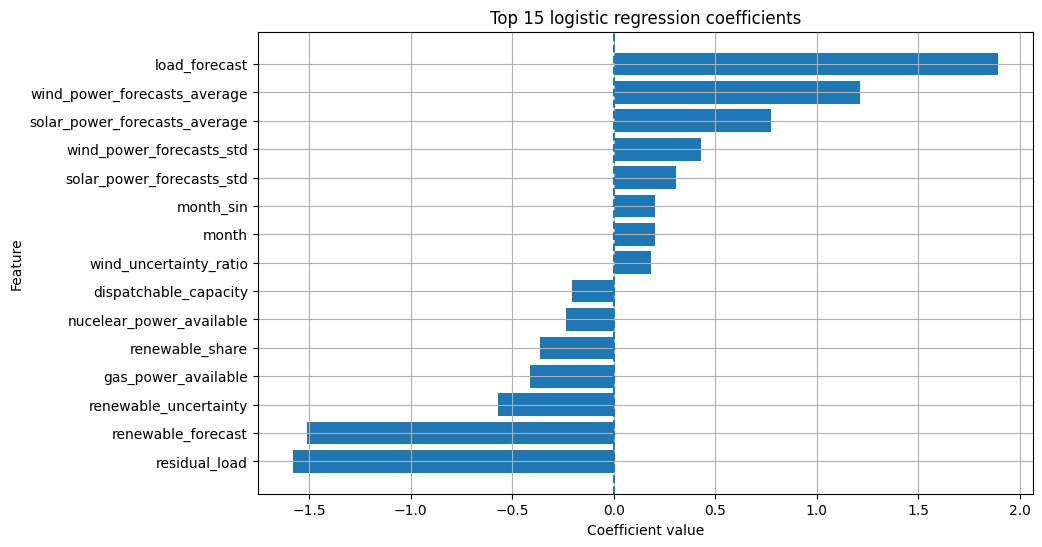


10. SUBMISSION SUMMARY
--------------------------------------------------------------------------------
Submission shape: (4942, 2)
Submission columns: ['DELIVERY_START', 'spot_id_delta']

Prediction counts:
spot_id_delta
 1    2908
-1    2034
Name: count, dtype: int64


,DELIVERY_START,spot_id_delta
0,2023-04-02 00:00:00+02:00,1
1,2023-04-02 01:00:00+02:00,1
2,2023-04-02 02:00:00+02:00,1
3,2023-04-02 03:00:00+02:00,1
4,2023-04-02 04:00:00+02:00,1



11. FINAL CONCLUSION
--------------------------------------------------------------------------------

The objective of this project was to predict the direction of the price spread between 
the Intraday electricity market and the Day-Ahead Spot market.

The benchmark consisted in always predicting a positive spread, meaning that Intraday 
prices are expected to be higher than Spot prices.

Several models were tested:
- Logistic Regression
- Random Forest
- HistGradientBoosting
- Weighted Logistic Regression
- Capped Weighted Logistic Regression

The best standalone model was the Capped Weighted Logistic Regression, trained with 
sample weights based on the absolute value of the observed spread. This choice is 
consistent with the challenge metric, since large price spreads are more important 
than small ones.

A hybrid strategy was then tested: the model was used on most hours, while the 
benchmark prediction was kept for hours where the benchmark outperformed the model 
on the valid

In [ ]:
# ============================================================
# FINAL RECAP — PROJECT 140 ELECTRICITY PRICES PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("=" * 80)
print("PROJECT 140 — ELECTRICITY PRICES PREDICTION")
print("Final recap of methodology, results and model interpretation")
print("=" * 80)

# ------------------------------------------------------------
# 1. DATASET OVERVIEW
# ------------------------------------------------------------

print("\n1. DATASET OVERVIEW")
print("-" * 80)

print("Train period:", df_features["DELIVERY_START"].min(), "to", df_features["DELIVERY_START"].max())
print("Number of training rows:", len(df_features))
print("Number of explanatory features used:", len(feature_cols))

if "X_test_features" in globals():
    print("Test period:", X_test_features["DELIVERY_START"].min(), "to", X_test_features["DELIVERY_START"].max())
    print("Number of test rows:", len(X_test_features))

target_summary = df_features["spot_id_delta"].describe()
display(target_summary)

positive_share = (df_features["spot_id_delta"] > 0).mean()
negative_share = (df_features["spot_id_delta"] < 0).mean()

print("Share of positive spreads:", round(positive_share, 4))
print("Share of negative spreads:", round(negative_share, 4))


# ------------------------------------------------------------
# 2. TARGET DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.hist(df_features["spot_id_delta"], bins=100)
plt.title("Distribution of spot_id_delta")
plt.xlabel("Intraday - Spot price spread")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


plt.figure(figsize=(14, 5))
plt.plot(df_features["DELIVERY_START"], df_features["spot_id_delta"])
plt.title("Evolution of spot_id_delta over time")
plt.xlabel("Delivery date")
plt.ylabel("Intraday - Spot price spread")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 3. MODEL COMPARISON
# ------------------------------------------------------------

print("\n2. MODEL COMPARISON")
print("-" * 80)

display(model_comparison)

plt.figure(figsize=(10, 5))
ordered_models = model_comparison.sort_values("weighted_accuracy", ascending=True)
plt.barh(ordered_models["model"], ordered_models["weighted_accuracy"])
plt.title("Validation weighted accuracy by model")
plt.xlabel("Weighted accuracy")
plt.ylabel("Model")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 4. FINAL STRATEGY COMPARISON
# ------------------------------------------------------------

print("\n3. FINAL STRATEGY COMPARISON")
print("-" * 80)

display(final_comparison.sort_values("weighted_accuracy", ascending=False))

plt.figure(figsize=(9, 5))
ordered_strategy = final_comparison.sort_values("weighted_accuracy", ascending=True)
plt.barh(ordered_strategy["strategy"], ordered_strategy["weighted_accuracy"])
plt.title("Final validation weighted accuracy by strategy")
plt.xlabel("Weighted accuracy")
plt.ylabel("Strategy")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 5. BEST MODEL CONFUSION MATRIX
# ------------------------------------------------------------

print("\n4. BEST MODEL PERFORMANCE ON VALIDATION SET")
print("-" * 80)

print("Best model simple accuracy:", round(best_valid_accuracy, 4))
print("Best model weighted accuracy:", round(best_valid_weighted, 4))
print("Hybrid strategy weighted accuracy:", round(hybrid_weighted_accuracy, 4))
print("Benchmark weighted accuracy:", round(benchmark_valid_weighted, 4))

print("\nBest model classification report:")
print(classification_report(y_valid_class, y_valid_pred_class_best))

cm_best = confusion_matrix(y_valid_class, y_valid_pred_class_best)

plt.figure(figsize=(6, 5))
plt.imshow(cm_best)
plt.title("Confusion matrix — Best model")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(cm_best.shape[0]):
    for j in range(cm_best.shape[1]):
        plt.text(j, i, cm_best[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


# ------------------------------------------------------------
# 6. HYBRID STRATEGY CONFUSION MATRIX
# ------------------------------------------------------------

print("\n5. HYBRID STRATEGY PERFORMANCE")
print("-" * 80)

cm_hybrid = confusion_matrix(
    valid_analysis["true_class"],
    valid_analysis["hybrid_pred_class"]
)

print("Hybrid classification report:")
print(classification_report(
    valid_analysis["true_class"],
    valid_analysis["hybrid_pred_class"]
))

plt.figure(figsize=(6, 5))
plt.imshow(cm_hybrid)
plt.title("Confusion matrix — Hybrid strategy")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(cm_hybrid.shape[0]):
    for j in range(cm_hybrid.shape[1]):
        plt.text(j, i, cm_hybrid[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


# ------------------------------------------------------------
# 7. HOURLY PERFORMANCE ANALYSIS
# ------------------------------------------------------------

print("\n6. HOURLY PERFORMANCE ANALYSIS")
print("-" * 80)

display(hourly_comparison.sort_values("hour"))

plt.figure(figsize=(12, 5))
plt.plot(
    hourly_comparison["hour"],
    hourly_comparison["model_weighted_accuracy"],
    marker="o",
    label="Best model"
)
plt.plot(
    hourly_comparison["hour"],
    hourly_comparison["benchmark_weighted_accuracy"],
    marker="o",
    label="Benchmark always positive"
)
plt.axhline(
    benchmark_valid_weighted,
    linestyle="--",
    label="Global benchmark"
)

plt.title("Weighted accuracy by hour: model vs benchmark")
plt.xlabel("Hour of day")
plt.ylabel("Weighted accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 5))
plt.bar(
    hourly_comparison["hour"],
    hourly_comparison["improvement_vs_benchmark"]
)
plt.axhline(0, linestyle="--")
plt.title("Improvement of best model vs benchmark by hour")
plt.xlabel("Hour of day")
plt.ylabel("Weighted accuracy improvement")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 8. MONTHLY REGIME ANALYSIS
# ------------------------------------------------------------

print("\n7. MONTHLY REGIME ANALYSIS")
print("-" * 80)

display(monthly_benchmark)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_benchmark["month"],
    monthly_benchmark["benchmark_weighted_accuracy"],
    marker="o"
)
plt.title("Benchmark weighted accuracy by month")
plt.xlabel("Month")
plt.ylabel("Benchmark weighted accuracy")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 5))
plt.bar(
    monthly_benchmark["month"],
    monthly_benchmark["mean_delta"]
)
plt.axhline(0, linestyle="--")
plt.title("Average Intraday - Spot spread by month")
plt.xlabel("Month")
plt.ylabel("Average spot_id_delta")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 9. BACKTEST RESULTS
# ------------------------------------------------------------

print("\n8. TIME-BASED BACKTEST RESULTS")
print("-" * 80)

display(backtest_results)

backtest_summary_cols = [
    "benchmark_weighted",
    "model_weighted",
    "hybrid_weighted",
    "benchmark_simple",
    "model_simple",
    "hybrid_simple",
    "model_vs_benchmark",
    "hybrid_vs_benchmark"
]

display(backtest_results[backtest_summary_cols].mean().to_frame("average_score"))

plt.figure(figsize=(10, 5))
plt.plot(backtest_results["fold"], backtest_results["benchmark_weighted"], marker="o", label="Benchmark")
plt.plot(backtest_results["fold"], backtest_results["model_weighted"], marker="o", label="Model only")
plt.plot(backtest_results["fold"], backtest_results["hybrid_weighted"], marker="o", label="Hybrid")
plt.title("Backtest weighted accuracy by validation period")
plt.xlabel("Validation period")
plt.ylabel("Weighted accuracy")
plt.xticks(rotation=30)
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 10. FEATURE INTERPRETATION
# ------------------------------------------------------------

print("\n9. FEATURE INTERPRETATION")
print("-" * 80)

print("Top coefficients of the final logistic regression model:")
display(coef_df.head(15))

top_coef = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.axvline(0, linestyle="--")
plt.title("Top 15 logistic regression coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.grid(True)
plt.show()


# ------------------------------------------------------------
# 11. SUBMISSION SUMMARY
# ------------------------------------------------------------

print("\n10. SUBMISSION SUMMARY")
print("-" * 80)

if "submission" in globals():
    print("Submission shape:", submission.shape)
    print("Submission columns:", submission.columns.tolist())
    print("\nPrediction counts:")
    print(submission["spot_id_delta"].value_counts())
    display(submission.head())
else:
    print("No submission dataframe found.")


# ------------------------------------------------------------
# 12. FINAL WRITTEN CONCLUSION
# ------------------------------------------------------------

print("\n11. FINAL CONCLUSION")
print("-" * 80)

print("""
The objective of this project was to predict the direction of the price spread between
the Intraday electricity market and the Day-Ahead Spot market.

The benchmark consisted in always predicting a positive spread, meaning that Intraday
prices are expected to be higher than Spot prices.

Several models were tested:
- Logistic Regression
- Random Forest
- HistGradientBoosting
- Weighted Logistic Regression
- Capped Weighted Logistic Regression

The best standalone model was the Capped Weighted Logistic Regression, trained with
sample weights based on the absolute value of the observed spread. This choice is
consistent with the challenge metric, since large price spreads are more important
than small ones.

A hybrid strategy was then tested: the model was used on most hours, while the
benchmark prediction was kept for hours where the benchmark outperformed the model
on the validation set. This hybrid strategy achieved the best validation score.

However, the backtest showed that performance was not stable across all historical
periods. The model performed particularly well on the most recent validation period,
but less well on older periods. This suggests the presence of market regime changes,
which is a key limitation of the project.

Overall, the project shows that electricity price spread prediction is highly
regime-dependent and that combining machine learning with market-based feature
engineering and simple benchmark rules can improve directional forecasting.
""")

print("=" * 80)
print("END OF FINAL RECAP")
print("=" * 80)